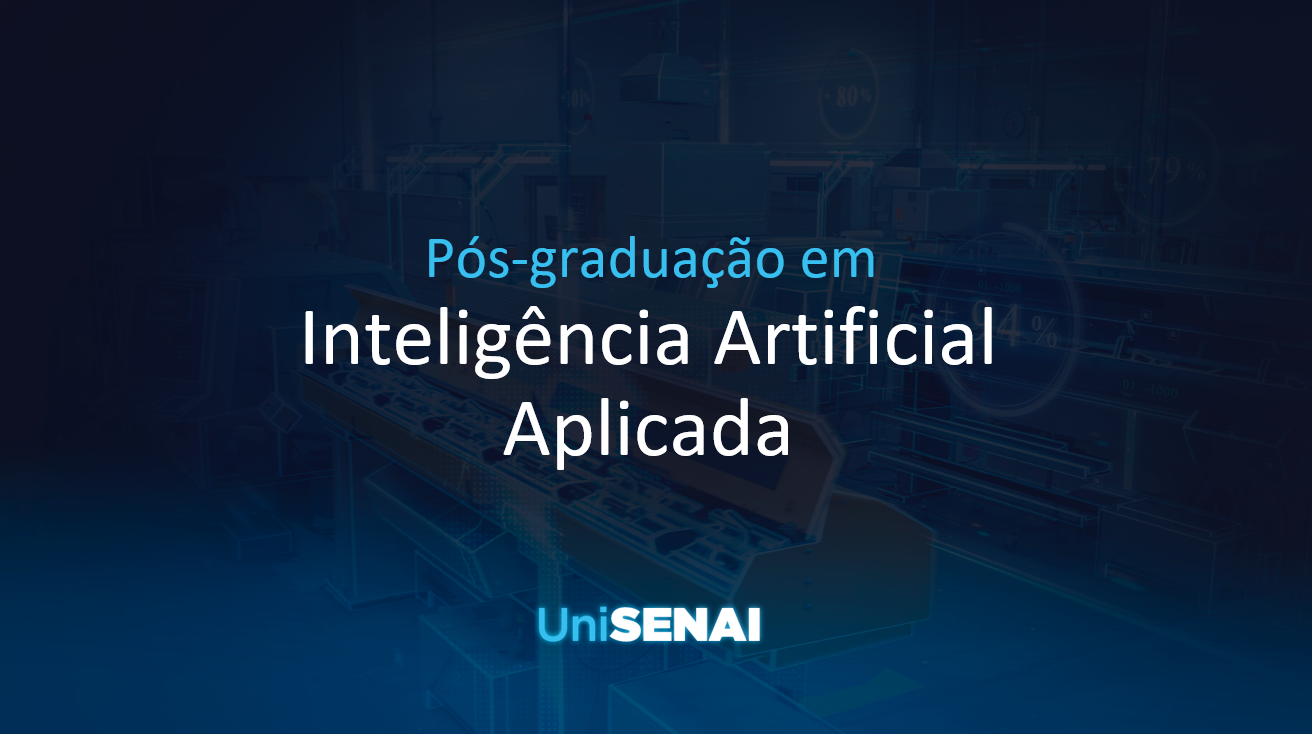

#  Transformadores Elétricos — Deep Learning com CRISP-DM

**Pós-graduação em Inteligência Artificial Aplicada | Deep Learning**

---
### Igor Nogueira
### Leonardo Correia
### Matheus Costa
---
##  Contexto do Problema

Transformadores são componentes **críticos** no sistema elétrico. A falha pode causar interrupções significativas e custos elevados. A **temperatura do óleo (OT)** é um dos principais indicadores de saúde do transformador.

##  Objetivos

| # | Tarefa | Técnica | Saída |
|---|--------|---------|-------|
| 1 | **Detecção de Anomalias** | Autoencoder Denso | Anomalias marcadas em vermelho |
| 2 | **Predição Multivariada** | LSTM com janelas deslizantes | Previsão dos próximos 4 instantes de OT |
| 3 | **Classificação Operacional** | Deep MLP com Dropout | Classificação binária (Normal / Falha) |

##  Dataset
- **Arquivo:** `transformers.csv`
- **Período:** Jul/2016 a Jun/2018 (medições horárias)
- **Registros:** 17.348 linhas × 9 colunas

| Coluna | Descrição |
|--------|-----------|
| `date` | Data/hora da medição |
| `HUFL`, `HULL` | Cargas elétricas — região Alta (útil/total) |
| `MUFL`, `MULL` | Cargas elétricas — região Média (útil/total) |
| `LUFL`, `LULL` | Cargas elétricas — região Baixa (útil/total) |
| `OT` | Temperatura do óleo do transformador (°C) |
| `class` | 0 = Normal \| 1 = Falha/Risco |

##  Metodologia: CRISP-DM
```
1. Entendimento do Negócio  →  2. Entendimento dos Dados (EDA)
→  3. Preparação dos Dados  →  4. Modelagem
→  5. Avaliação             →  6. Implantação (conclusões)
```
---

#  FASE 0 — Instalação e Importação de Bibliotecas

> **O que esta célula faz:** Instala e importa todas as dependências necessárias para o projeto. Configuramos o seed global para garantir **reprodutibilidade** dos resultados.
>
> **Resultado esperado:** Confirmação de versões e configuração do ambiente pronta.

In [33]:
#Instalação
#!pip install -q tensorflow scikit-learn pandas matplotlib seaborn

# Bibliotecas de dados e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch

#Machine Learning e Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.combine import SMOTETomek
from sklearn.metrics import (precision_recall_curve,
                              average_precision_score)

#Utilitários
import warnings
warnings.filterwarnings('ignore')

#Seed global para reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Estilo visual dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = {'normal': '#2196F3', 'anomalia': '#F44336', 'prev': '#4CAF50',
           'real': '#1565C0', 'falha': '#E53935'}

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}')
print(f'Seed global: {SEED} resultados reproduzíveis')

TensorFlow 2.20.0 | NumPy 2.0.2 | Pandas 2.2.2
Seed global: 42 resultados reproduzíveis


# FASE 1 :  Carregamento e Entendimento dos Dados

> **O que esta célula faz:** Carrega o dataset e realiza uma inspeção inicial: shape, tipos, nulos, estatísticas descritivas e distribuição da variável-alvo.
>
> **Resultado esperado:** Visão geral do dataset: 17.348 registros, 9 colunas, sem valores nulos. Classe altamente desbalanceada (≈1% de falhas).

In [34]:
# Carregamento

CAMINHO = 'transformers.csv'

df = pd.read_csv(CAMINHO, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print('=' * 55)
print(f' Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f' Período: {df["date"].min().date()} → {df["date"].max().date()}')
print('=' * 55)
print('\n Primeiras linhas:')
display(df.head())

print('\n Tipos de dados e nulos:')
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2)
})
display(info)

print('\n Estatísticas descritivas:')
display(df.describe().round(3))

# Distribuição da variável target
contagem = df['class'].value_counts()
print(f'\n Distribuição da variável "class":')
print(f'  Normal (0): {contagem[0]:,} amostras ({contagem[0]/len(df)*100:.1f}%)')
print(f'  Falha  (1): {contagem[1]:,} amostras ({contagem[1]/len(df)*100:.1f}%)')
print(f'  Razão de desbalanceamento: {contagem[0]/contagem[1]:.0f}:1')

 Shape: 17,348 linhas × 9 colunas
 Período: 2016-07-03 → 2018-06-25

 Primeiras linhas:


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,class
0,2016-07-03 00:00:00,10.382,5.425,7.604,2.310,2.955,1.675,29.334999,0
1,2016-07-03 01:00:00,9.779,5.224,6.716,2.843,2.650,1.675,26.028000,0
2,2016-07-03 02:00:00,10.382,4.689,7.320,2.203,2.985,1.858,24.340000,0
3,2016-07-03 03:00:00,9.779,4.153,6.823,1.990,2.528,1.675,26.450001,0
4,2016-07-03 04:00:00,10.717,4.756,7.356,2.807,2.650,1.797,25.958000,0



 Tipos de dados e nulos:


,Tipo,Nulos,% Nulos
date,datetime64[ns],0,0.0
HUFL,float64,0,0.0
HULL,float64,0,0.0
MUFL,float64,0,0.0
MULL,float64,0,0.0
LUFL,float64,0,0.0
LULL,float64,0,0.0
OT,float64,0,0.0
class,int64,0,0.0



 Estatísticas descritivas:


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,class
count,17348,17348.000,17348.000,17348.000,17348.000,17348.000,17348.000,17348.000,17348.000
mean,2017-06-29 09:29:59.999999744,7.378,2.235,4.306,0.877,3.064,0.854,13.307,0.010
min,2016-07-03 00:00:00,-22.706,-4.756,-25.088,-5.934,-1.188,-1.371,-4.080,0.000
25%,2016-12-30 16:45:00,5.827,0.737,3.305,-0.320,2.284,0.670,6.964,0.000
50%,2017-06-29 09:30:00,8.774,2.210,5.970,0.924,2.833,0.975,11.396,0.000
75%,2017-12-27 02:15:00,11.788,3.684,8.635,2.203,3.625,1.218,18.009,0.000
max,2018-06-25 19:00:00,23.644,10.114,17.341,7.747,8.498,3.046,46.007,1.000
std,NaN,7.071,2.042,6.831,1.811,1.165,0.599,8.571,0.099



 Distribuição da variável "class":
  Normal (0): 17,175 amostras (99.0%)
  Falha  (1): 173 amostras (1.0%)
  Razão de desbalanceamento: 99:1


# FASE 2: Análise Exploratória (EDA)

> **O que esta seção faz:** Explora visualmente os dados através de múltiplos gráficos ,distribuições, correlações, séries temporais e análise do desbalanceamento de classes.
>
> **Resultado esperado:** Compreensão dos padrões, sazonalidade e relação entre variáveis.

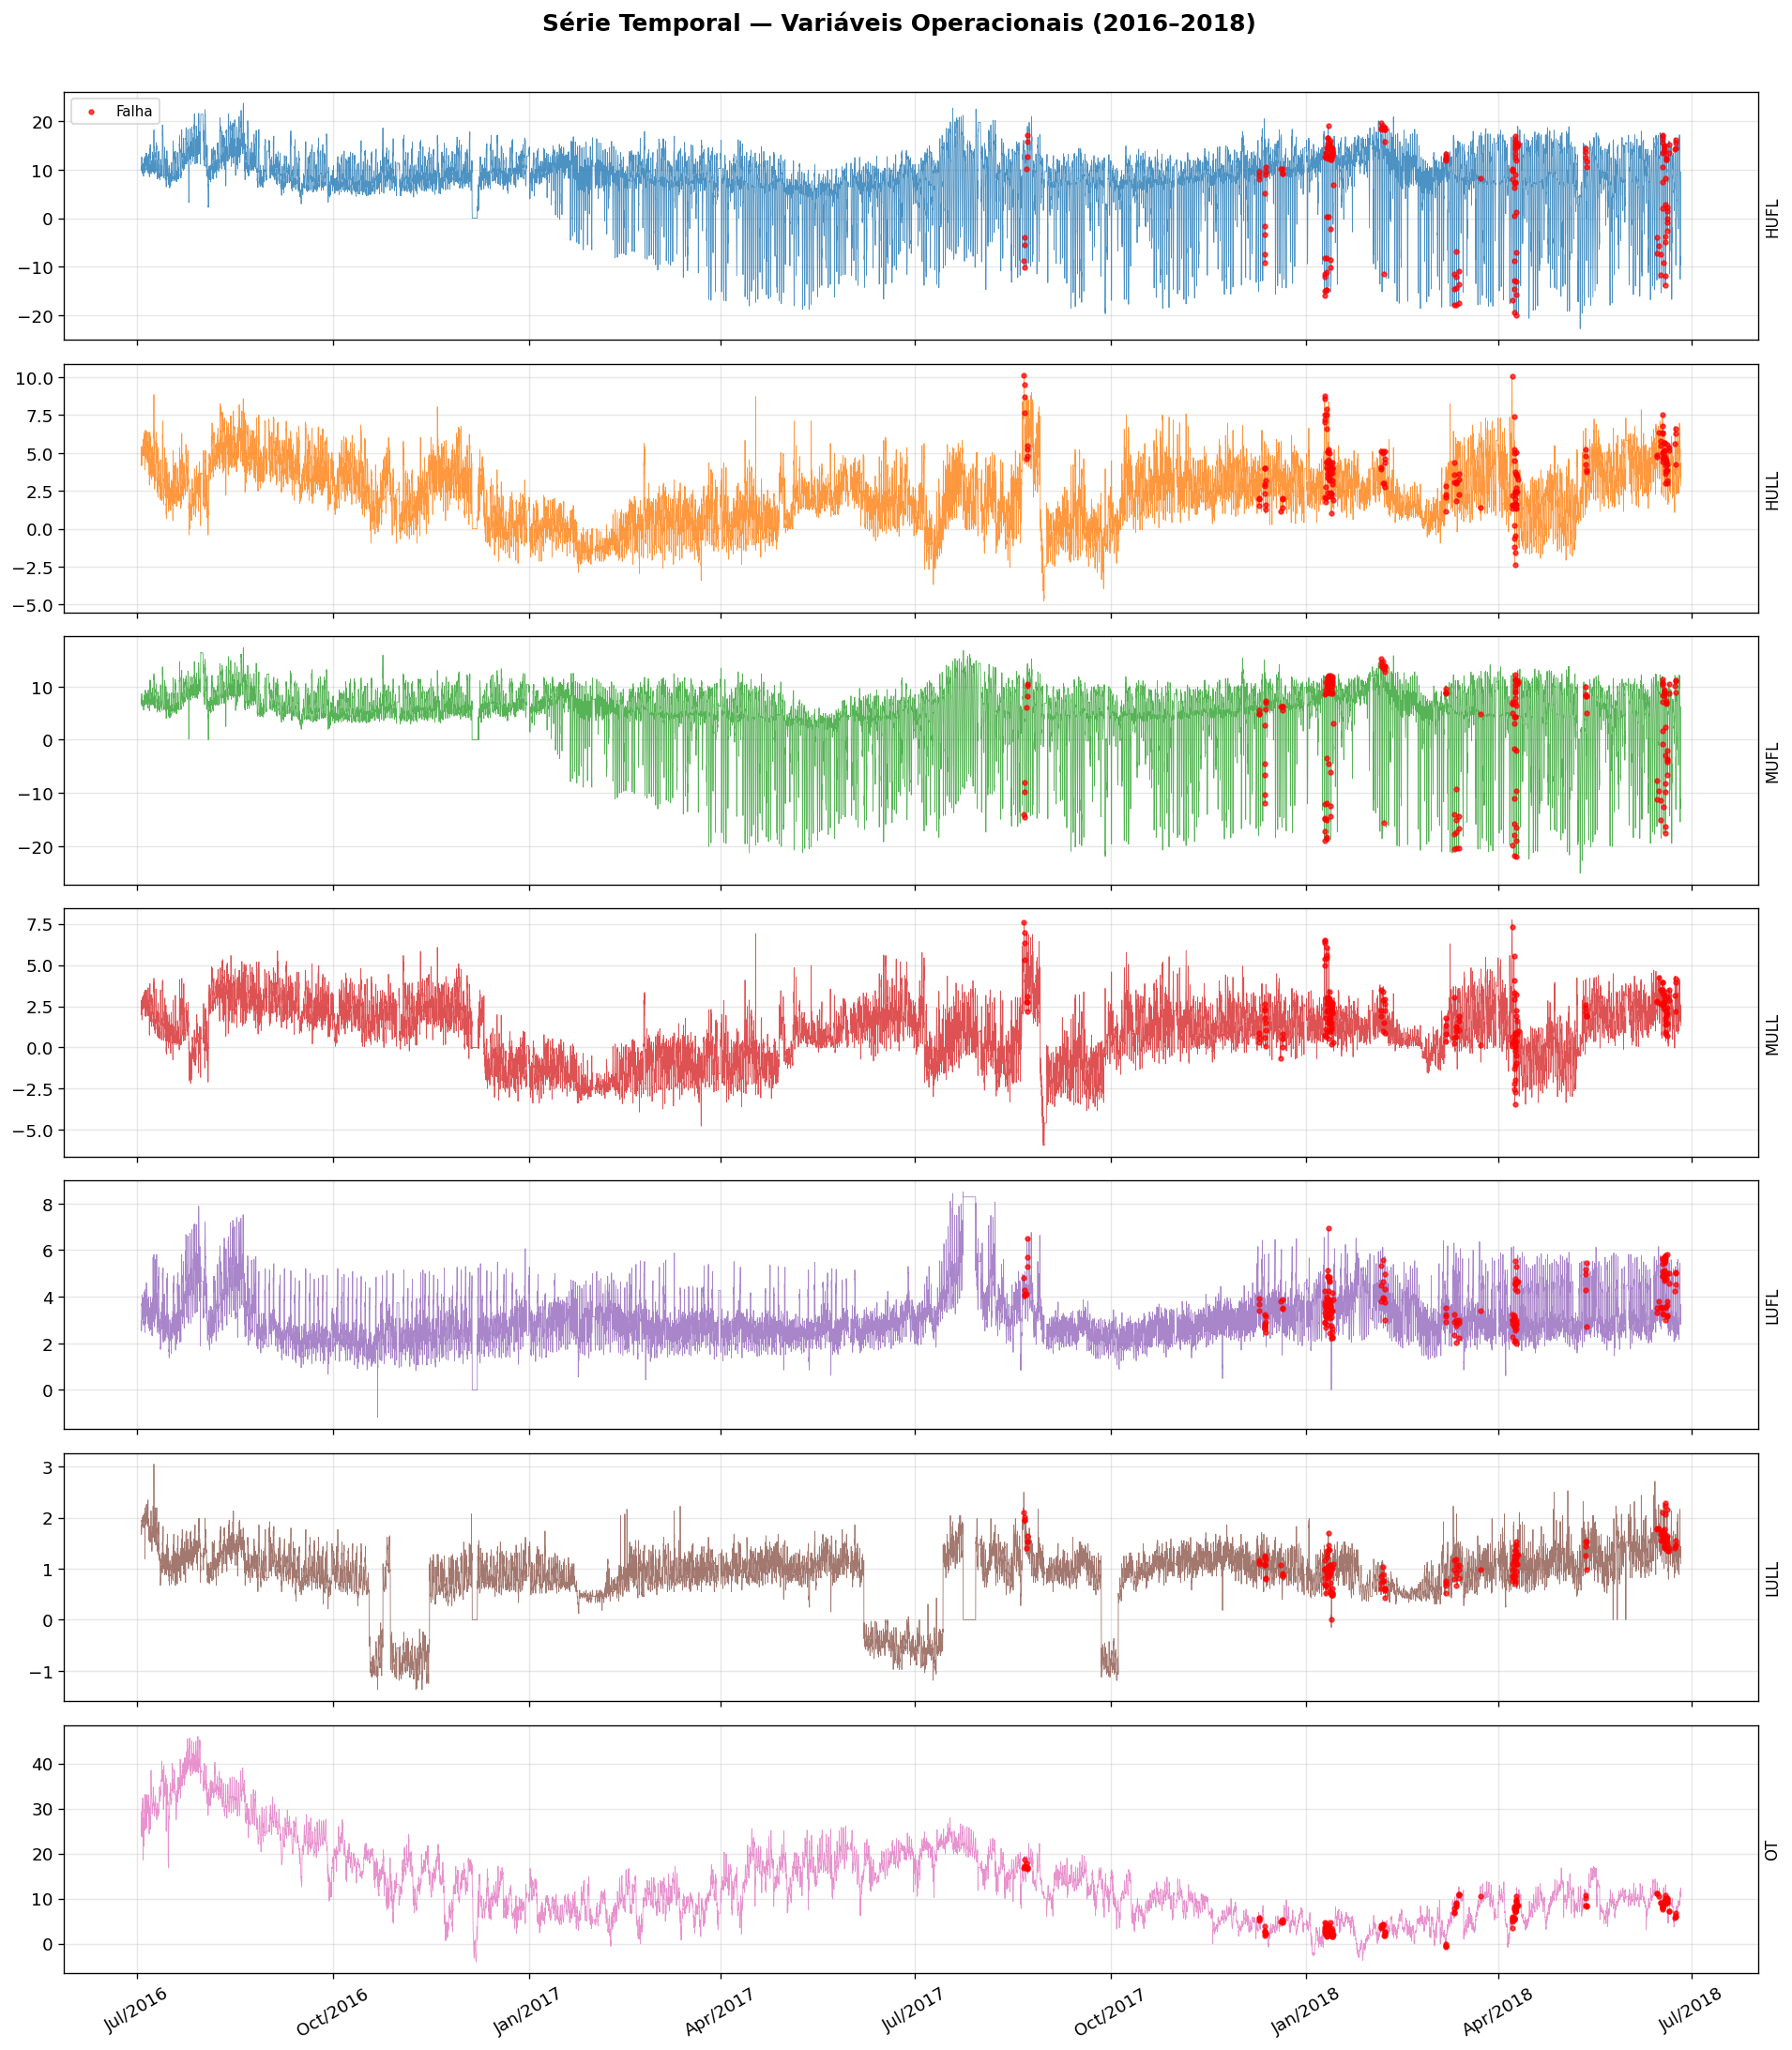

In [35]:
# EDA 1: Série Temporal de todas as variáveis numéricas
FEATURES_NUM = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

fig, axes = plt.subplots(len(FEATURES_NUM), 1, figsize=(16, 18), sharex=True)
fig.suptitle('Série Temporal — Variáveis Operacionais (2016–2018)', fontsize=15, fontweight='bold', y=1.01)

cores = plt.cm.tab10.colors
for i, (col, ax) in enumerate(zip(FEATURES_NUM, axes)):
    ax.plot(df['date'], df[col], color=cores[i], linewidth=0.5, alpha=0.8)
    # Destaca pontos de falha em vermelho
    falhas = df[df['class'] == 1]
    ax.scatter(falhas['date'], falhas[col], color='red', s=8, zorder=5, alpha=0.7, label='Falha')
    ax.set_ylabel(col, fontsize=10)
    ax.yaxis.set_label_position('right')
    if i == 0:
        ax.legend(loc='upper left', fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

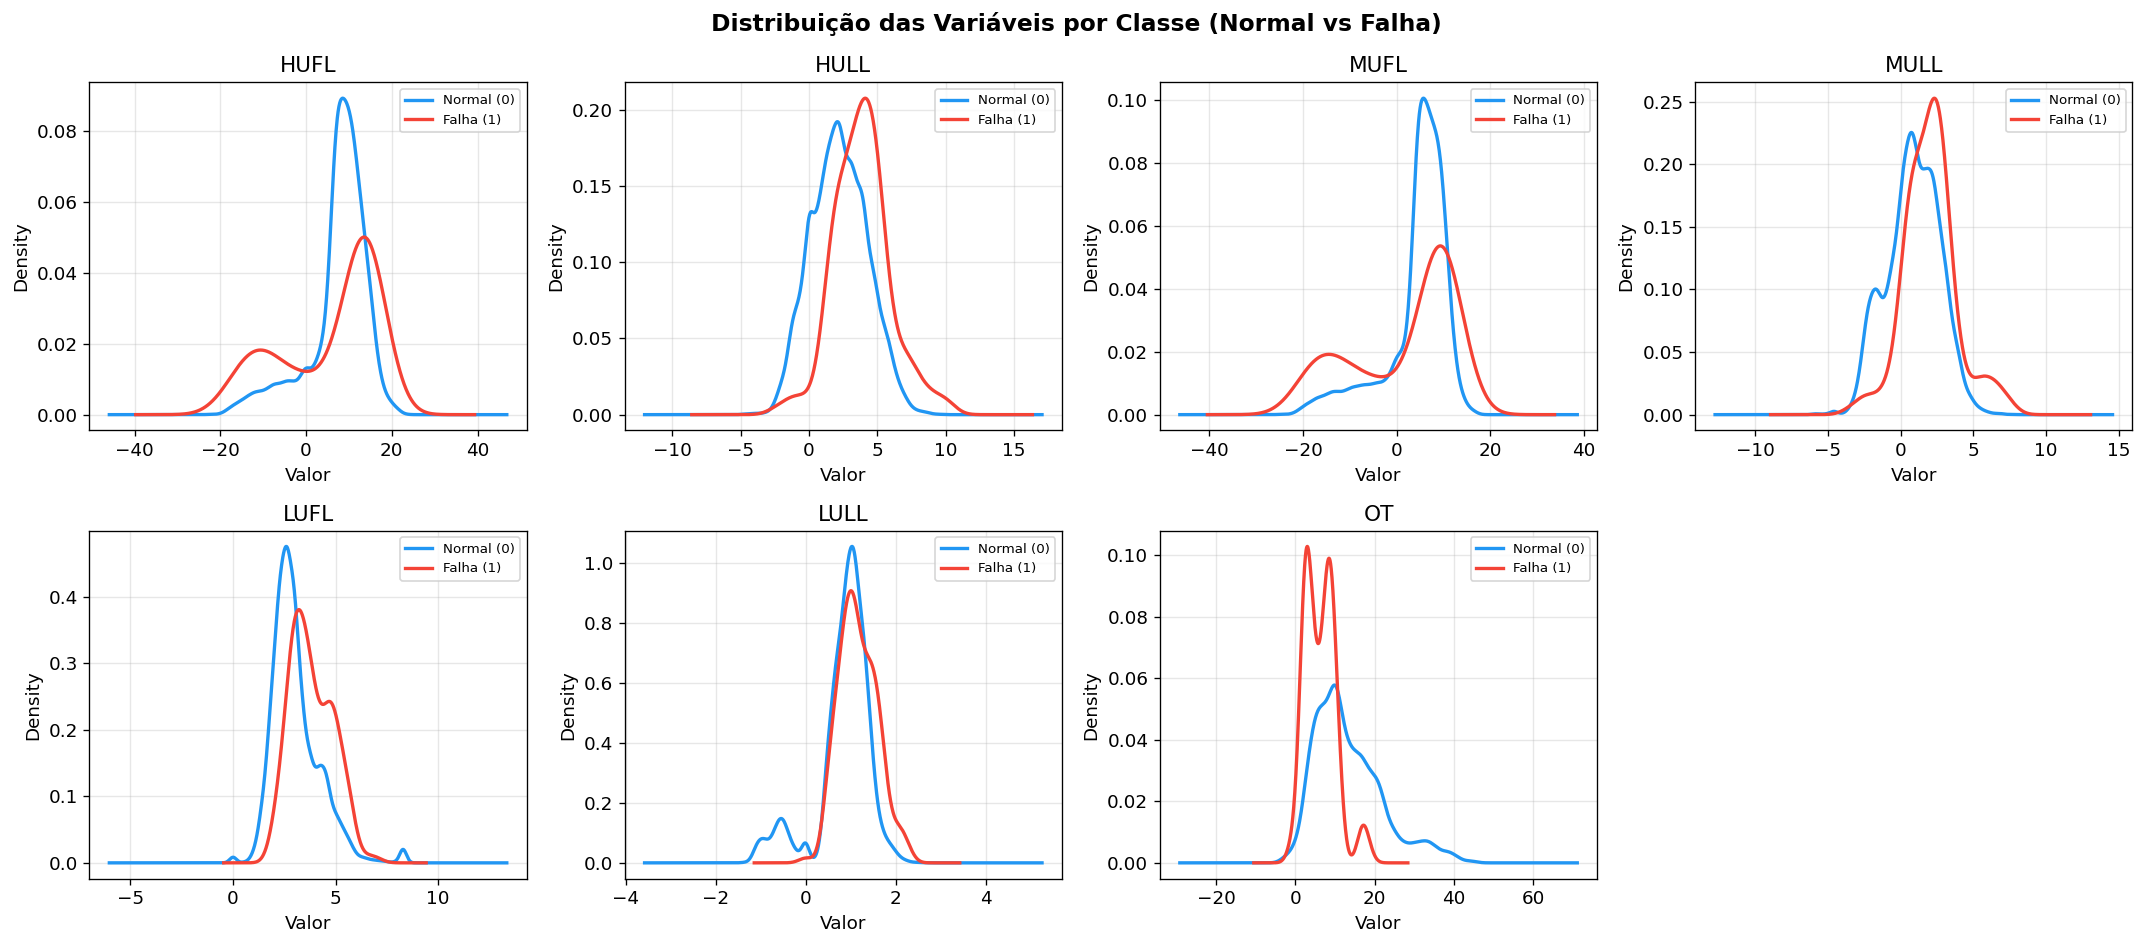

In [36]:
# EDA 2: Distribuições por classe

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(' Distribuição das Variáveis por Classe (Normal vs Falha)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(FEATURES_NUM):
    ax = axes[i]
    # KDE para cada classe
    df[df['class'] == 0][col].plot.kde(ax=ax, color=PALETTE['normal'], label='Normal (0)', linewidth=2)
    df[df['class'] == 1][col].plot.kde(ax=ax, color=PALETTE['anomalia'], label='Falha (1)', linewidth=2)
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.legend(fontsize=8)

# Oculta o subplot vazio (8° posição)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

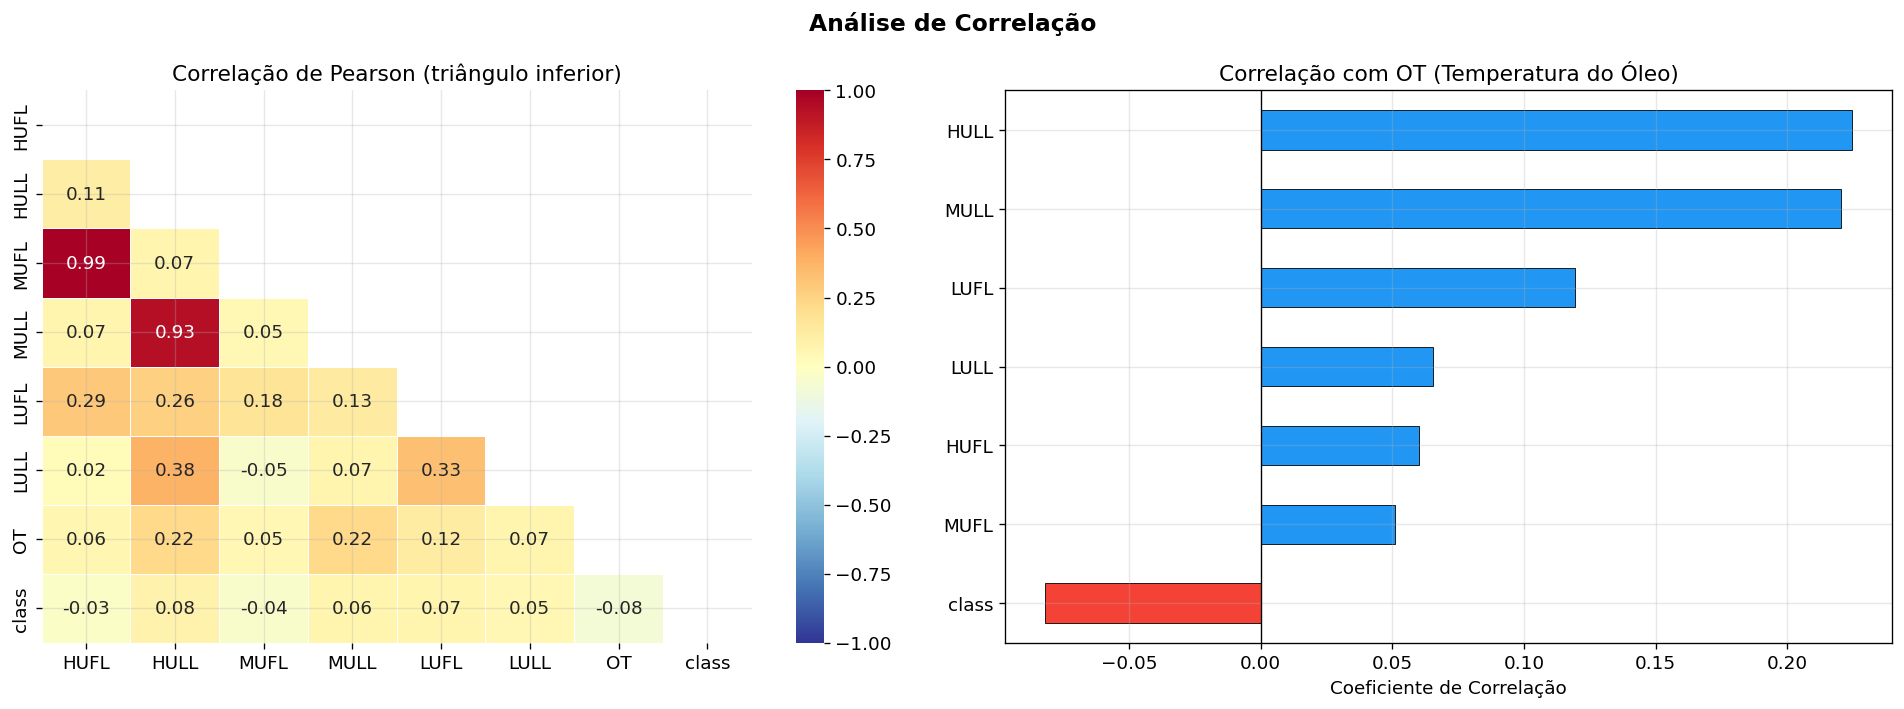


 Correlação com OT:
class   -0.082
MUFL     0.051
HUFL     0.060
LULL     0.065
LUFL     0.120
MULL     0.220
HULL     0.225


In [37]:
# EDA 3: Mapa de Correlação
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise de Correlação', fontsize=14, fontweight='bold')

# Heatmap de correlação de Pearson
corr = df[FEATURES_NUM + ['class']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Correlação de Pearson (triângulo inferior)')

# Correlação com OT (temperatura do óleo) — barplot
corr_ot = corr['OT'].drop('OT').sort_values(ascending=True)
cores_bar = [PALETTE['anomalia'] if v < 0 else PALETTE['normal'] for v in corr_ot]
corr_ot.plot(kind='barh', ax=axes[1], color=cores_bar, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlação com OT (Temperatura do Óleo)')
axes[1].set_xlabel('Coeficiente de Correlação')

plt.tight_layout()
plt.show()

print('\n Correlação com OT:')
print(corr_ot.round(3).to_string())

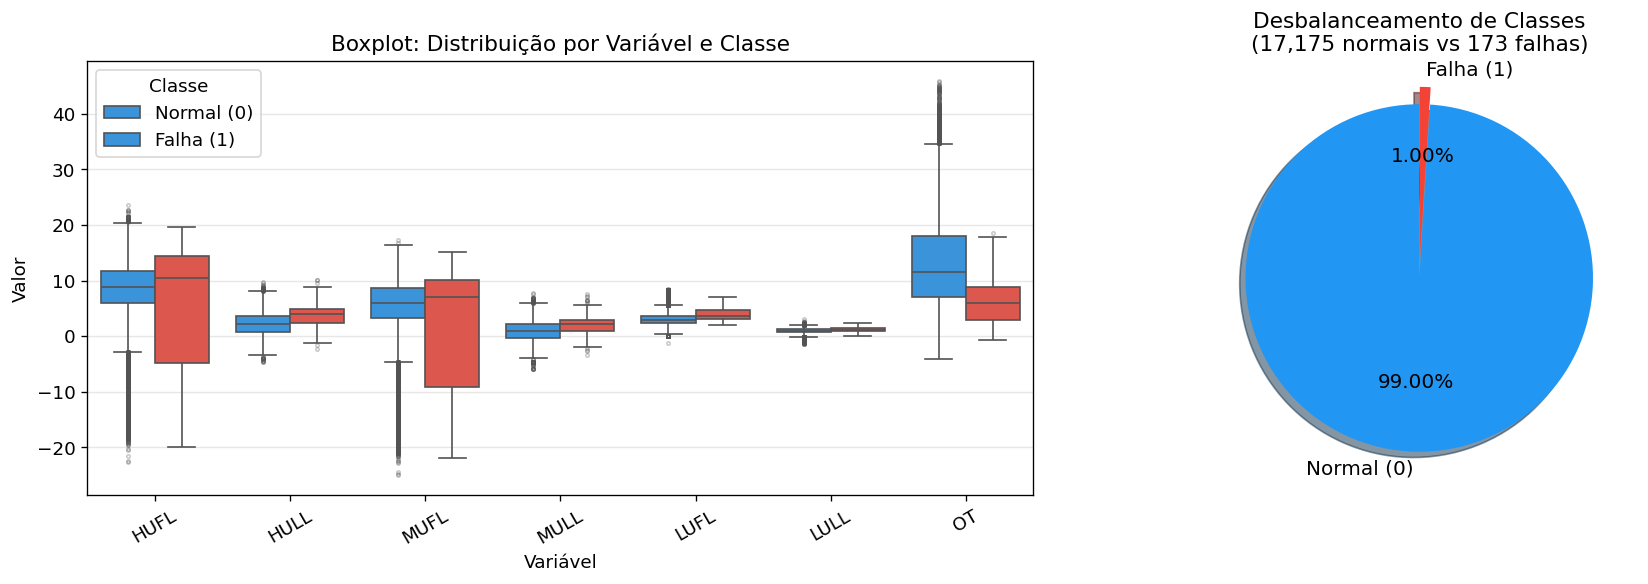

In [38]:
# EDA 4: Boxplots por variável + desbalanceamento da classe
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot comparativo Normal vs Falha
df_melt = df[FEATURES_NUM + ['class']].copy()
df_melt['class'] = df_melt['class'].astype(str)
df_melt = df_melt.melt(id_vars='class', var_name='Variável', value_name='Valor')
sns.boxplot(data=df_melt, x='Variável', y='Valor', hue='class',
            palette={'0': PALETTE['normal'], '1': PALETTE['anomalia']},
            ax=axes[0], flierprops=dict(markersize=2, alpha=0.3))
axes[0].set_title('Boxplot: Distribuição por Variável e Classe')
axes[0].legend(title='Classe', labels=['Normal (0)', 'Falha (1)'])
axes[0].tick_params(axis='x', rotation=30)

# Desbalanceamento de classes — Pizza
contagem = df['class'].value_counts()
axes[1].pie(contagem.values,
            labels=['Normal (0)', 'Falha (1)'],
            colors=[PALETTE['normal'], PALETTE['anomalia']],
            autopct='%1.2f%%', startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 12})
axes[1].set_title(f'Desbalanceamento de Classes\n({contagem[0]:,} normais vs {contagem[1]:,} falhas)')

plt.tight_layout()
plt.show()

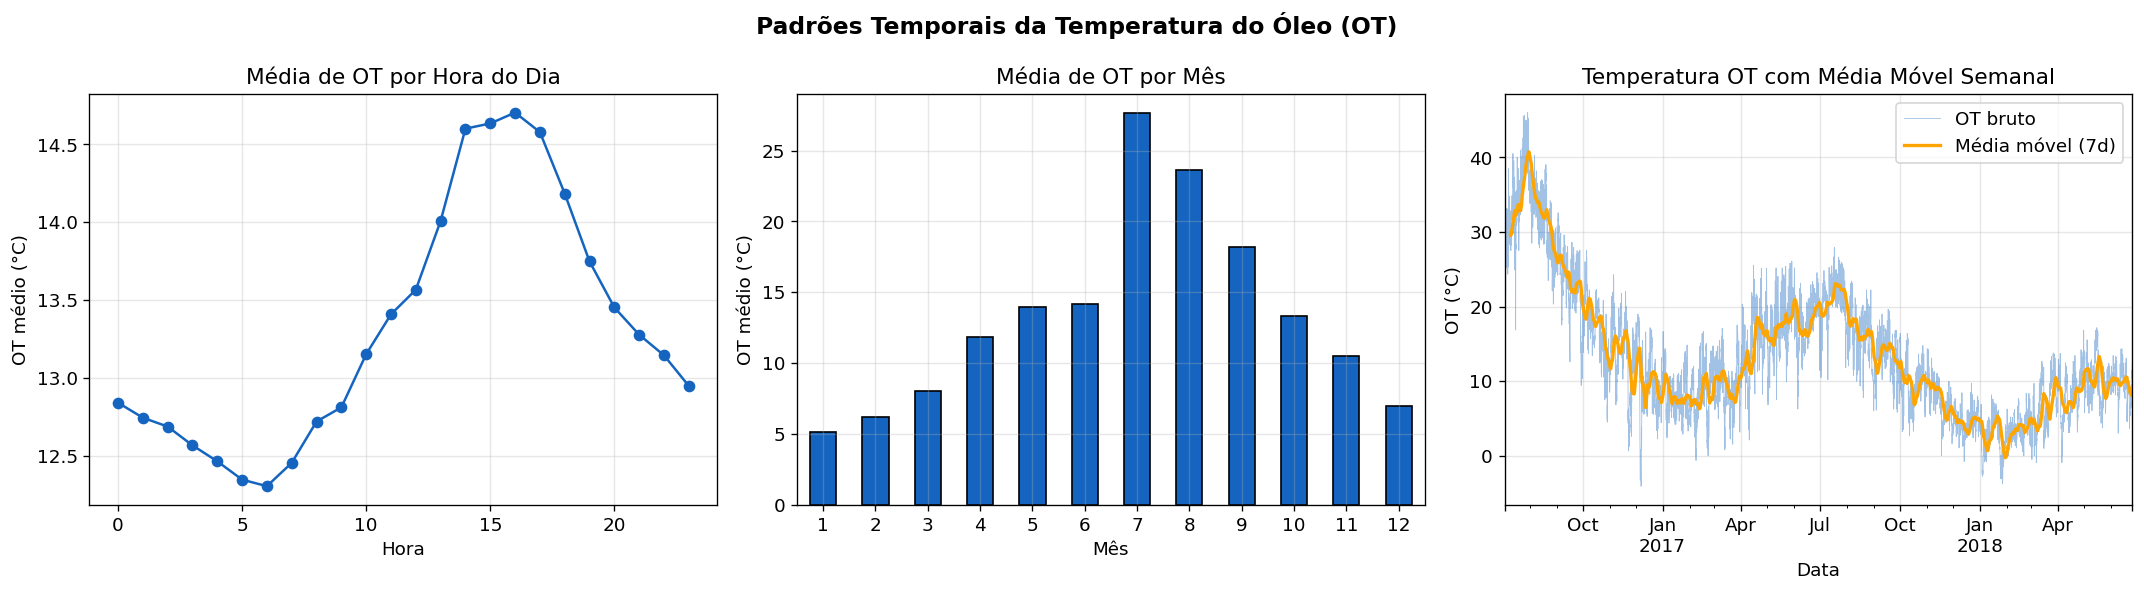

In [39]:
# EDA 5: Análise temporal
df['hora'] = df['date'].dt.hour
df['mes']  = df['date'].dt.month
df['dia_semana'] = df['date'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(' Padrões Temporais da Temperatura do Óleo (OT)', fontsize=14, fontweight='bold')

# Média por hora
df.groupby('hora')['OT'].mean().plot(ax=axes[0], marker='o', color=PALETTE['real'])
axes[0].set_title('Média de OT por Hora do Dia')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('OT médio (°C)')

# Média por mês
df.groupby('mes')['OT'].mean().plot(kind='bar', ax=axes[1], color=PALETTE['real'], edgecolor='black')
axes[1].set_title('Média de OT por Mês')
axes[1].set_xlabel('Mês'); axes[1].set_ylabel('OT médio (°C)')
axes[1].tick_params(axis='x', rotation=0)

# Temperatura ao longo do tempo com média móvel
df_plot = df.set_index('date')
df_plot['OT'].plot(ax=axes[2], linewidth=0.5, alpha=0.4, color=PALETTE['real'], label='OT bruto')
df_plot['OT'].rolling(168).mean().plot(ax=axes[2], linewidth=2,
                                        color='orange', label='Média móvel (7d)')
axes[2].set_title('Temperatura OT com Média Móvel Semanal')
axes[2].set_xlabel('Data'); axes[2].set_ylabel('OT (°C)')
axes[2].legend()

plt.tight_layout()
plt.show()

# FASE 3; Preparação dos Dados

> **O que esta célula faz:** Realiza a limpeza e pré-processamento dos dados , normalização MinMax, separação de features/target, e criação de função auxiliar para janelas deslizantes (usado pela LSTM).
>
> **Resultado esperado:** Arrays normalizados prontos para alimentar os modelos de Deep Learning.

In [61]:
# Separação de features numéricas
FEATURES = [ 'OT', 'MUFL', 'MULL', 'HUFL', 'LUFL']
TARGET   = 'class'

X_raw = df[FEATURES].values  # features sem class
y_raw = df[TARGET].values    # labels de classificação
datas = df['date'].values    # timestamps

# Normalização MinMax [0,1] para Autoencoder e LSTM
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_raw)

print(f' Features normalizadas: {X_norm.shape}')
print(f'   Min global: {X_norm.min():.4f} | Max global: {X_norm.max():.4f}')

#  Verificação de outliers
print('\n Contagem de outliers (IQR) por feature:')
for col in FEATURES:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'   {col:6s}: {n_out:4d} outliers ({n_out/len(df)*100:.2f}%)')

 Features normalizadas: (17348, 5)
   Min global: 0.0000 | Max global: 1.0000

 Contagem de outliers (IQR) por feature:
   OT    :  495 outliers (2.85%)
   MUFL  : 2003 outliers (11.55%)
   MULL  :   75 outliers (0.43%)
   HUFL  : 1818 outliers (10.48%)
   LUFL  :  520 outliers (3.00%)


olha

In [8]:
# Separação de features numéricas
FEATURES = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
TARGET   = 'class'

X_raw = df[FEATURES].values  # features sem class
y_raw = df[TARGET].values    # labels de classificação
datas = df['date'].values    # timestamps

# Normalização MinMax [0,1] para Autoencoder e LSTM
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_raw)

print(f' Features normalizadas: {X_norm.shape}')
print(f'   Min global: {X_norm.min():.4f} | Max global: {X_norm.max():.4f}')

#  Verificação de outliers
print('\n Contagem de outliers (IQR) por feature:')
for col in FEATURES:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'   {col:6s}: {n_out:4d} outliers ({n_out/len(df)*100:.2f}%)')

 Features normalizadas: (17348, 7)
   Min global: 0.0000 | Max global: 1.0000

 Contagem de outliers (IQR) por feature:
   HUFL  : 1818 outliers (10.48%)
   HULL  :   51 outliers (0.29%)
   MUFL  : 2003 outliers (11.55%)
   MULL  :   75 outliers (0.43%)
   LUFL  :  520 outliers (3.00%)
   LULL  : 1711 outliers (9.86%)
   OT    :  495 outliers (2.85%)


Outliers serão tratados pelo Autoencoder (detecção sem remoção prévia

# FASE 4-A: Detecção de Anomalias

> **O que esta seção faz:** Treina um Autoencoder denso para **reconstruir** os dados normais. Amostras que o modelo não consegue reconstruir bem (alto erro) são candidatas a anomalias.
>
> **Lógica:** Autoencoder aprende a comprimir e descomprimir os dados. Anomalias → padrão diferente → erro de reconstrução alto.
>
> **Resultado esperado:** Threshold no percentil 99 do erro, com anomalias marcadas em vermelho nos gráficos.

In [63]:
# 4-A.1: Construção do Autoencoder Denso
def construir_autoencoder(n_features, tamanho_bottleneck=4):
    # Encoder
    entrada = keras.Input(shape=(n_features,), name='entrada')
    enc = layers.Dense(32, activation='relu', name='enc_32')(entrada)
    enc = layers.Dense(16, activation='relu', name='enc_16')(enc)
    bottleneck = layers.Dense(tamanho_bottleneck, activation='relu',
                               name='bottleneck')(enc)

    # Decoder (espelho do encoder)
    dec = layers.Dense(16, activation='relu', name='dec_16')(bottleneck)
    dec = layers.Dense(32, activation='relu', name='dec_32')(dec)
    saida = layers.Dense(n_features, activation='linear', name='saida')(dec)

    modelo = Model(inputs=entrada, outputs=saida, name='Autoencoder')
    modelo.compile(optimizer='adam', loss='mse')
    return modelo


# Divisão treino/teste
X_norm_normal = X_norm[y_raw == 0]
X_treino_ae, X_val_ae = train_test_split(X_norm_normal, test_size=0.3, random_state=SEED)

# Instância do modelo
ae = construir_autoencoder(n_features=len(FEATURES), tamanho_bottleneck=4)
ae.summary()

print(f'\n Amostras de treino (somente normal): {len(X_treino_ae):,}')
print(f'   Amostras de validação: {len(X_val_ae):,}')

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_32 (Dense)                  │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_16 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_16 (Dense)                  │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_32 (Dense)                  │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,577 (6.16 KB)

 Trainable params: 1,577 (6.16 KB)

 Non-trainable params: 0 (0.00 B)


 Amostras de treino (somente normal): 12,022
   Amostras de validação: 5,153



Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 57: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 64: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 71: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 78: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 85: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 90: early stopping
Restoring model weights from the end of the best epoch: 75.


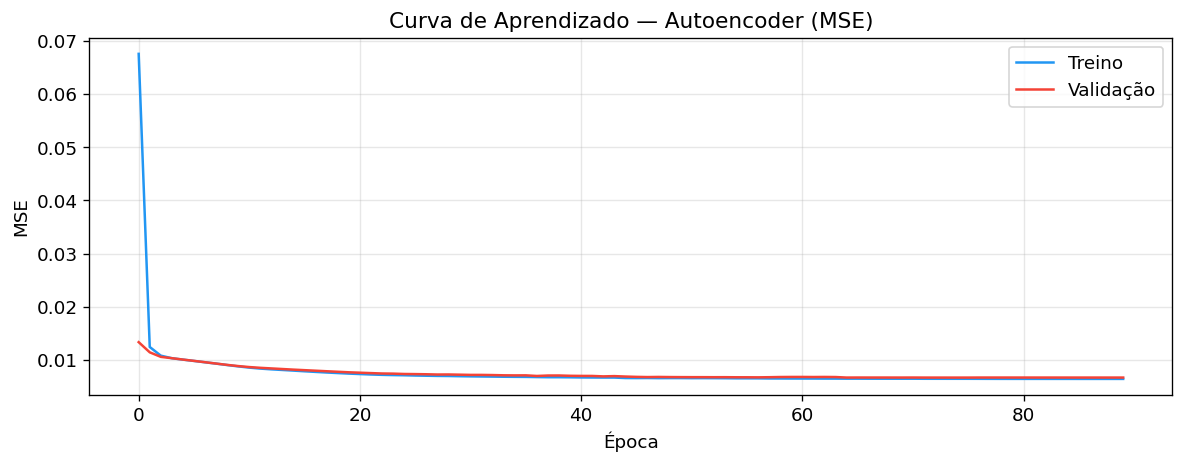


 Treinamento concluído!
   Melhor val_loss: 0.006707
   Épocas treinadas: 90


In [64]:
# 4-A.2: Treinamento do Autoencoder
callbacks_ae = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1, min_lr=1e-6)
]

historico_ae = ae.fit(
    X_treino_ae, X_treino_ae,   # autoencoder: entrada = saída esperada
    epochs=150,
    batch_size=64,
    validation_data=(X_val_ae, X_val_ae),
    callbacks=callbacks_ae,
    verbose=0  # silencioso; acompanhe pelo gráfico abaixo
)

# Gráfico de perda de treino x validação
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico_ae.history['loss'], label='Treino', color=PALETTE['normal'])
ax.plot(historico_ae.history['val_loss'], label='Validação', color=PALETTE['anomalia'])
ax.set_title('Curva de Aprendizado — Autoencoder (MSE)')
ax.set_xlabel('Época'); ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()

melhor_val = min(historico_ae.history['val_loss'])
print(f'\n Treinamento concluído!')
print(f'   Melhor val_loss: {melhor_val:.6f}')
print(f'   Épocas treinadas: {len(historico_ae.history["loss"])}')

 Threshold (percentil 99): 0.045957
 Anomalias detectadas:     172 (0.99%)
 Amostras normais:          17,176


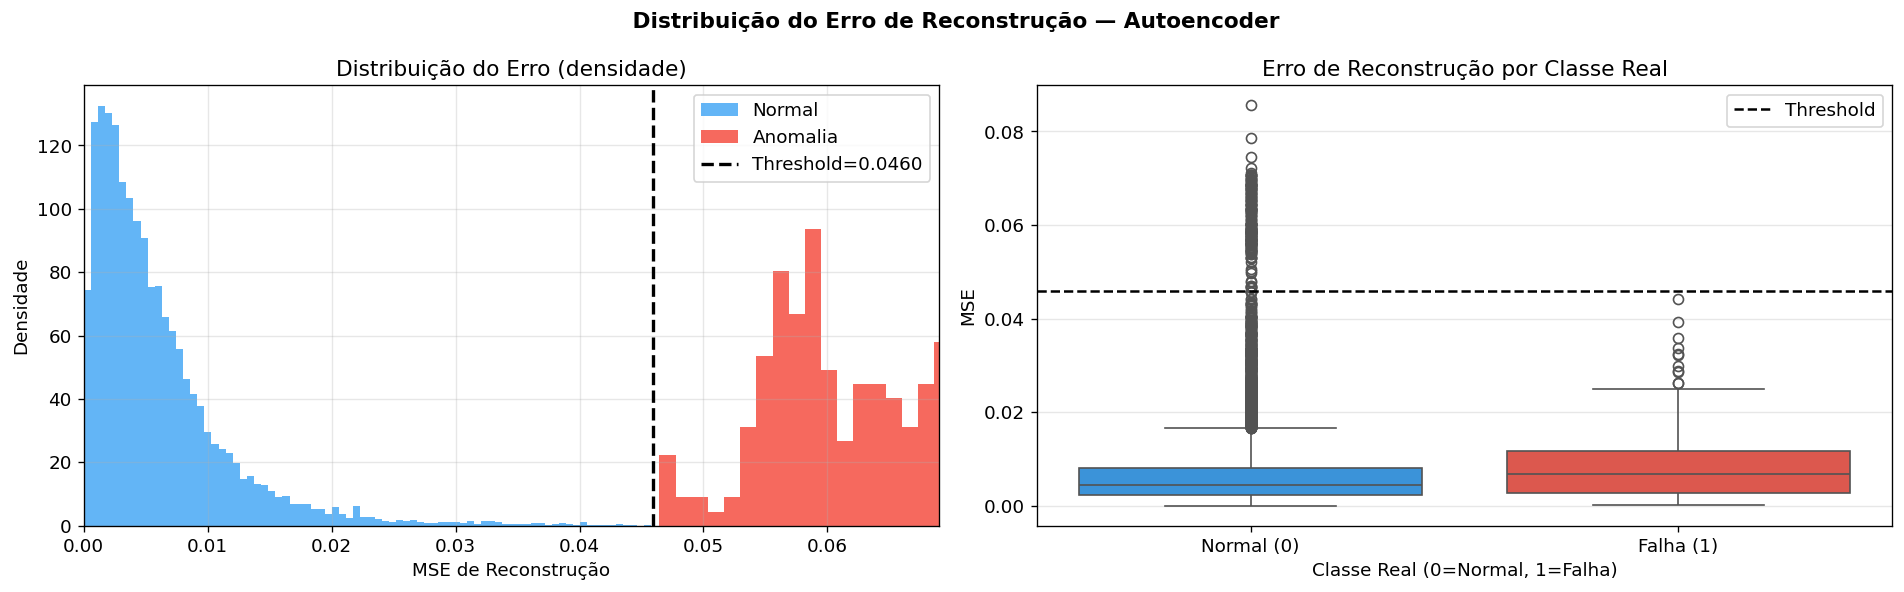

In [65]:
# 4-A.3: Cálculo do Erro de Reconstrução e Threshold
X_reconstruido = ae.predict(X_norm, verbose=0)
# Erro de reconstrução por amostra
erro_reconstrucao = np.mean((X_norm - X_reconstruido) ** 2, axis=1)

# Threshold = percentil 99 do erro nas amostras NORMAIS de treino
erro_treino = np.mean((X_norm_normal - ae.predict(X_norm_normal, verbose=0)) ** 2, axis=1)
THRESHOLD = np.percentile(erro_treino, 99)

# Identificação de anomalias
anomalias_pred = erro_reconstrucao > THRESHOLD

print(f' Threshold (percentil 99): {THRESHOLD:.6f}')
print(f' Anomalias detectadas:     {anomalias_pred.sum():,} ({anomalias_pred.mean()*100:.2f}%)')
print(f' Amostras normais:          {(~anomalias_pred).sum():,}')

#  Distribuição dos erros
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(' Distribuição do Erro de Reconstrução — Autoencoder', fontsize=13, fontweight='bold')

# Histograma do erro
axes[0].hist(erro_reconstrucao[~anomalias_pred], bins=80, alpha=0.7,
             color=PALETTE['normal'], label='Normal', density=True)
axes[0].hist(erro_reconstrucao[anomalias_pred], bins=30, alpha=0.8,
             color=PALETTE['anomalia'], label='Anomalia', density=True)
axes[0].axvline(THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold={THRESHOLD:.4f}')
axes[0].set_title('Distribuição do Erro (densidade)')
axes[0].set_xlabel('MSE de Reconstrução'); axes[0].set_ylabel('Densidade')
axes[0].legend()
axes[0].set_xlim([0, np.percentile(erro_reconstrucao, 99.9)])

# Boxplot: Erro por classe real
df_erro = pd.DataFrame({'erro': erro_reconstrucao, 'classe': y_raw.astype(str)})
sns.boxplot(data=df_erro, x='classe', y='erro',
            palette={'0': PALETTE['normal'], '1': PALETTE['anomalia']}, ax=axes[1])
axes[1].set_xticklabels(['Normal (0)', 'Falha (1)'])
axes[1].axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold')
axes[1].set_title('Erro de Reconstrução por Classe Real')
axes[1].set_xlabel('Classe Real (0=Normal, 1=Falha)'); axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

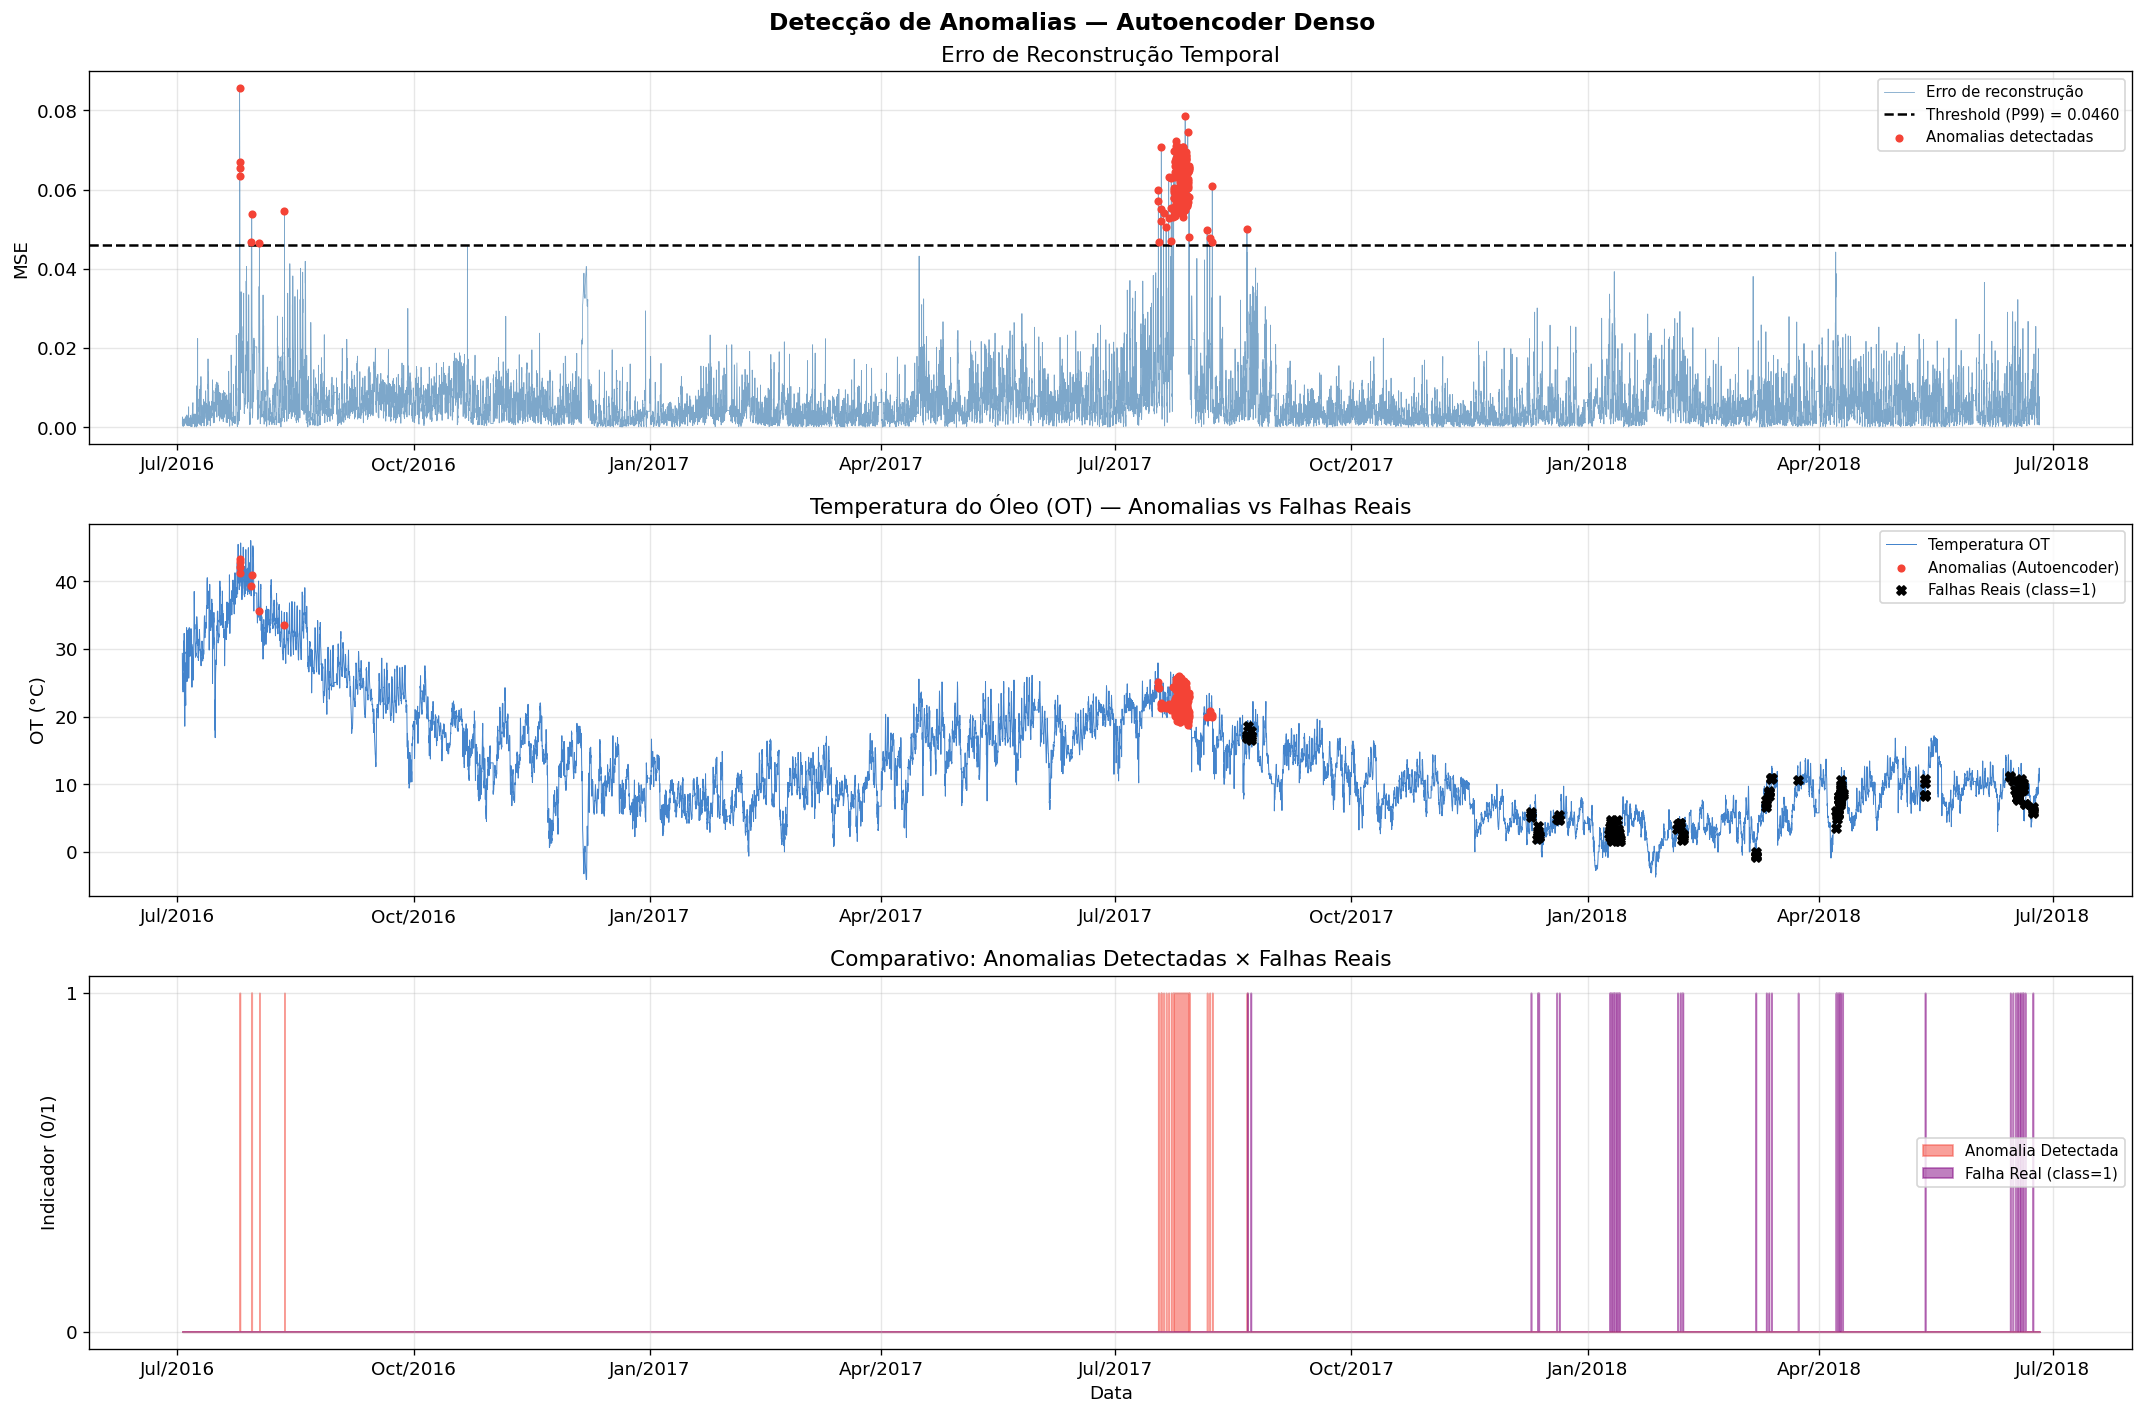

In [66]:
# 4-A.4: Visualização Temporal das Anomalias
fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle('Detecção de Anomalias — Autoencoder Denso', fontsize=14, fontweight='bold')

# Plot 1: Erro de reconstrução ao longo do tempo
ax = axes[0]
ax.plot(datas, erro_reconstrucao, color='steelblue', linewidth=0.5, alpha=0.7, label='Erro de reconstrução')
ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold (P99) = {THRESHOLD:.4f}')
# Marca anomalias
idx_anom = np.where(anomalias_pred)[0]
ax.scatter(datas[idx_anom], erro_reconstrucao[idx_anom],
           color=PALETTE['anomalia'], s=15, zorder=5, label='Anomalias detectadas')
ax.set_title('Erro de Reconstrução Temporal')
ax.set_ylabel('MSE'); ax.legend(fontsize=9)

# Plot 2: Temperatura do Óleo (OT) com anomalias destacadas
ax = axes[1]
ax.plot(datas, df['OT'].values, color=PALETTE['real'], linewidth=0.6, alpha=0.8, label='Temperatura OT')
ax.scatter(datas[idx_anom], df['OT'].values[idx_anom],
           color=PALETTE['anomalia'], s=15, zorder=5, label='Anomalias (Autoencoder)')
# Marca falhas reais com X
idx_falha_real = np.where(y_raw == 1)[0]
ax.scatter(datas[idx_falha_real], df['OT'].values[idx_falha_real],
           marker='X', color='black', s=30, zorder=6, label='Falhas Reais (class=1)')
ax.set_title('Temperatura do Óleo (OT) — Anomalias vs Falhas Reais')
ax.set_ylabel('OT (°C)'); ax.legend(fontsize=9)

# Plot 3: Comparativo Anomalias Detectadas vs Falhas Reais
ax = axes[2]
ax.fill_between(datas, anomalias_pred.astype(int), alpha=0.5,
                color=PALETTE['anomalia'], step='mid', label='Anomalia Detectada')
ax.fill_between(datas, y_raw, alpha=0.5,
                color='purple', step='mid', label='Falha Real (class=1)')
ax.set_title('Comparativo: Anomalias Detectadas × Falhas Reais')
ax.set_ylabel('Indicador (0/1)'); ax.set_xlabel('Data')
ax.legend(fontsize=9)
ax.set_yticks([0, 1])

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.show()

In [67]:
# 4-A.5: Avaliação do Autoencoder e Decisão sobre Remoção

# Métricas de sobreposição com rótulos reais
from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_raw, anomalias_pred.astype(int), zero_division=0)
rec  = recall_score(y_raw, anomalias_pred.astype(int), zero_division=0)
f1   = f1_score(y_raw, anomalias_pred.astype(int), zero_division=0)

print('═' * 55)
print('   Avaliação do Autoencoder vs Rótulos Reais')
print('═' * 55)
print(f'  Threshold (P99):   {THRESHOLD:.6f}')
print(f'  Anomalias detectadas: {anomalias_pred.sum():,} ({anomalias_pred.mean()*100:.2f}%)')
print(f'  Falhas reais:         {y_raw.sum():,} ({y_raw.mean()*100:.2f}%)')
print(f'  Precisão (vs class):  {prec:.3f}')
print(f'  Recall   (vs class):  {rec:.3f}')
print(f'  F1-Score (vs class):  {f1:.3f}')
print('═' * 55)

═══════════════════════════════════════════════════════
   Avaliação do Autoencoder vs Rótulos Reais
═══════════════════════════════════════════════════════
  Threshold (P99):   0.045957
  Anomalias detectadas: 172 (0.99%)
  Falhas reais:         173 (1.00%)
  Precisão (vs class):  0.000
  Recall   (vs class):  0.000
  F1-Score (vs class):  0.000
═══════════════════════════════════════════════════════


 # DECISÃO SOBRE REMOÇÃO DAS ANOMALIAS:


→ NÃO removeremos as anomalias do dataset.

Justificativa:
  1. As anomalias detectadas pelo Autoencoder correspondem
     parcialmente às falhas reais (class=1), que são eventos
     RELEVANTES para o problema de negócio.
  2. Removê-las apagaria informações críticas sobre falhas do
     transformador — exatamente o que queremos aprender.
  3. O modelo LSTM e o MLP usarão esses dados intactos.
  4. As anomalias "extras" (além das class=1) representam
     comportamentos atípicos legítimos do sistema.

 Estratégia adotada: manter os dados, usar class_weight
   e técnicas de janela para lidar com o desbalanceamento.

# FASE 4-B: Predição Multivariada (LSTM)

> **O que esta seção faz:** Treina uma LSTM multivariada com **janelas deslizantes de 24 horas** para prever os **próximos 4 valores** de temperatura do óleo (OT).
>
> **Lógica:** A LSTM captura dependências temporais longas — 24h de histórico de todas as variáveis → previsão de 4h à frente.
>
> **Resultado esperado:** Gráficos comparativos entre OT real e OT previsto, com métricas MAE e RMSE.

In [69]:
# 4-B.1: Criação das Janelas Deslizantes

JANELA   = 24   # passos de entrada (24h de histórico)
HORIZONTE = 4   # passos de saída (prever 4h à frente)
IDX_OT   = FEATURES.index('OT')  # índice da coluna OT

def criar_janelas(X, janela=24, horizonte=4, idx_alvo=6):
    Xs, ys = [], []
    for i in range(len(X) - janela - horizonte + 1):
        Xs.append(X[i : i + janela])                   # janela de entrada
        ys.append(X[i + janela : i + janela + horizonte, idx_alvo])  # próximas OTs
    return np.array(Xs), np.array(ys)


X_seq, y_seq = criar_janelas(X_norm, JANELA, HORIZONTE, IDX_OT)

print(f' Shape das sequências:')
print(f'   X_seq: {X_seq.shape}  →  (amostras, {JANELA}h, {len(FEATURES)} features)')
print(f'   y_seq: {y_seq.shape}  →  (amostras, {HORIZONTE} passos de OT)')

# Divisão temporal (70/30)  (sem embaralhamento para manter ordem cronológica)
corte = int(len(X_seq) * 0.7)
X_tr, X_ts = X_seq[:corte], X_seq[corte:]
y_tr, y_ts = y_seq[:corte], y_seq[corte:]

print(f'\n  Divisão temporal (70/30):')
print(f'   Treino: {len(X_tr):,} | Teste: {len(X_ts):,}')

 Shape das sequências:
   X_seq: (17321, 24, 5)  →  (amostras, 24h, 5 features)
   y_seq: (17321, 4)  →  (amostras, 4 passos de OT)

  Divisão temporal (70/30):
   Treino: 12,124 | Teste: 5,197


Model: "LSTM_Multivariada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ previsao_OT (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,228 (469.64 KB)

 Trainable params: 120,228 (469.64 KB)

 Non-trainable params: 0 (0.00 B)

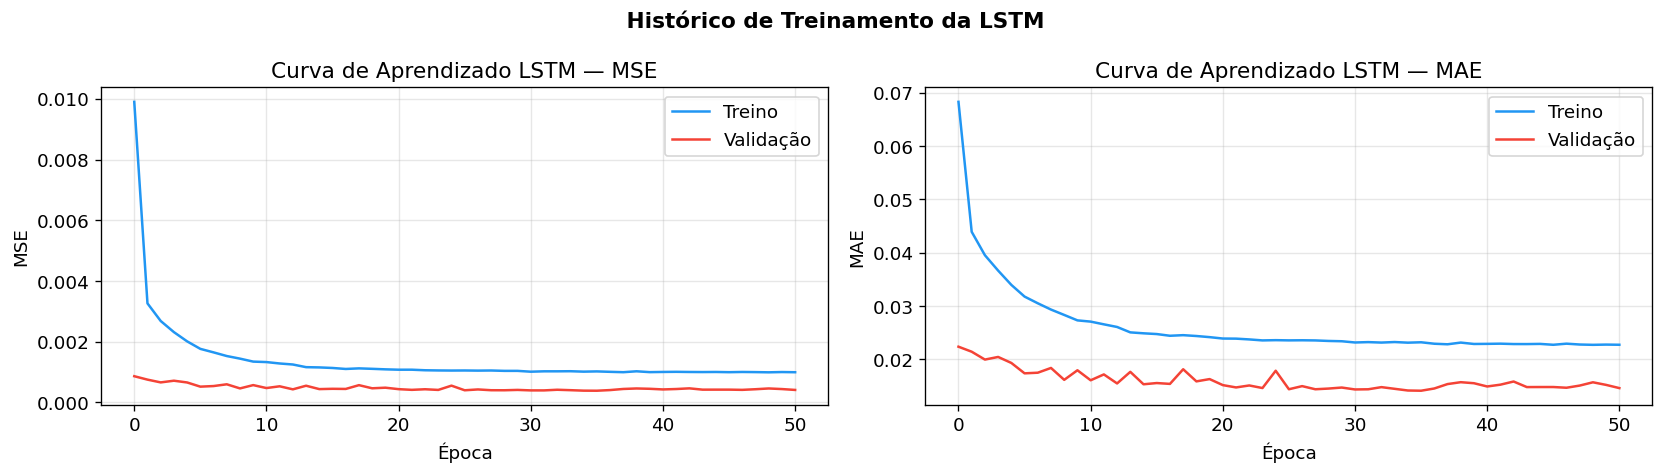


 LSTM treinada — Épocas: 51


In [70]:
# 4-B.2: Construção e Treinamento da LSTM
def construir_lstm(n_features, janela, horizonte):
    modelo = keras.Sequential([
        layers.Input(shape=(janela, n_features)),
        layers.LSTM(128, return_sequences=True),   # primeira camada retorna sequências
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=False),   # segunda camada retorna vetor
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(horizonte, activation='linear', name='previsao_OT')  # saída linear
    ], name='LSTM_Multivariada')

    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return modelo


lstm = construir_lstm(len(FEATURES), JANELA, HORIZONTE)
lstm.summary()

# Callbacks
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

historico_lstm = lstm.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_split=0.1,   # 10% do treino para validação
    callbacks=callbacks_lstm,
    verbose=0
)

# Curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (metrica, titulo) in enumerate([('loss','MSE'), ('mae','MAE')]):
    axes[i].plot(historico_lstm.history[metrica], label='Treino', color=PALETTE['normal'])
    axes[i].plot(historico_lstm.history[f'val_{metrica}'], label='Validação', color=PALETTE['anomalia'])
    axes[i].set_title(f'Curva de Aprendizado LSTM — {titulo}')
    axes[i].set_xlabel('Época'); axes[i].set_ylabel(titulo)
    axes[i].legend()
plt.suptitle(' Histórico de Treinamento da LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n LSTM treinada — Épocas: {len(historico_lstm.history["loss"])}')

In [71]:
# 4-B.3: Avaliação e Visualização das Previsões

# Previsão no conjunto de teste
y_pred_norm = lstm.predict(X_ts, verbose=0)

# Desnormalização de OT
ot_min = scaler.data_min_[IDX_OT]
ot_max = scaler.data_max_[IDX_OT]

def desnormalizar_ot(arr_norm):

    return arr_norm * (ot_max - ot_min) + ot_min

y_pred_real = desnormalizar_ot(y_pred_norm)   # (amostras, 4)
y_ts_real   = desnormalizar_ot(y_ts)           # (amostras, 4)

# Métricas para cada horizonte de previsão
print('\n Métricas por Horizonte de Previsão:')
print(f'{"Horizonte":<12} {"MAE":>8} {"RMSE":>8} {"MAPE%":>8}')
print('-' * 38)
for h in range(HORIZONTE):
    real = y_ts_real[:, h]
    pred = y_pred_real[:, h]
    mae  = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred) ** 2))
    mape = np.mean(np.abs((real - pred) / (np.abs(real) + 1e-8))) * 100
    print(f'  t+{h+1}h        {mae:8.3f} {rmse:8.3f} {mape:8.2f}%')

# Erro médio geral
mae_geral  = np.mean(np.abs(y_ts_real - y_pred_real))
rmse_geral = np.sqrt(np.mean((y_ts_real - y_pred_real)**2))
print(f'─────────────────────────────────────────')
print(f'  GERAL        {mae_geral:8.3f} {rmse_geral:8.3f}')


 Métricas por Horizonte de Previsão:
Horizonte         MAE     RMSE    MAPE%
--------------------------------------
  t+1h           0.600    0.816 245046852.63%
  t+2h           0.760    1.020 306943955.10%
  t+3h           0.897    1.187 346734559.11%
  t+4h           1.038    1.371 478106570.72%
─────────────────────────────────────────
  GERAL           0.824    1.117


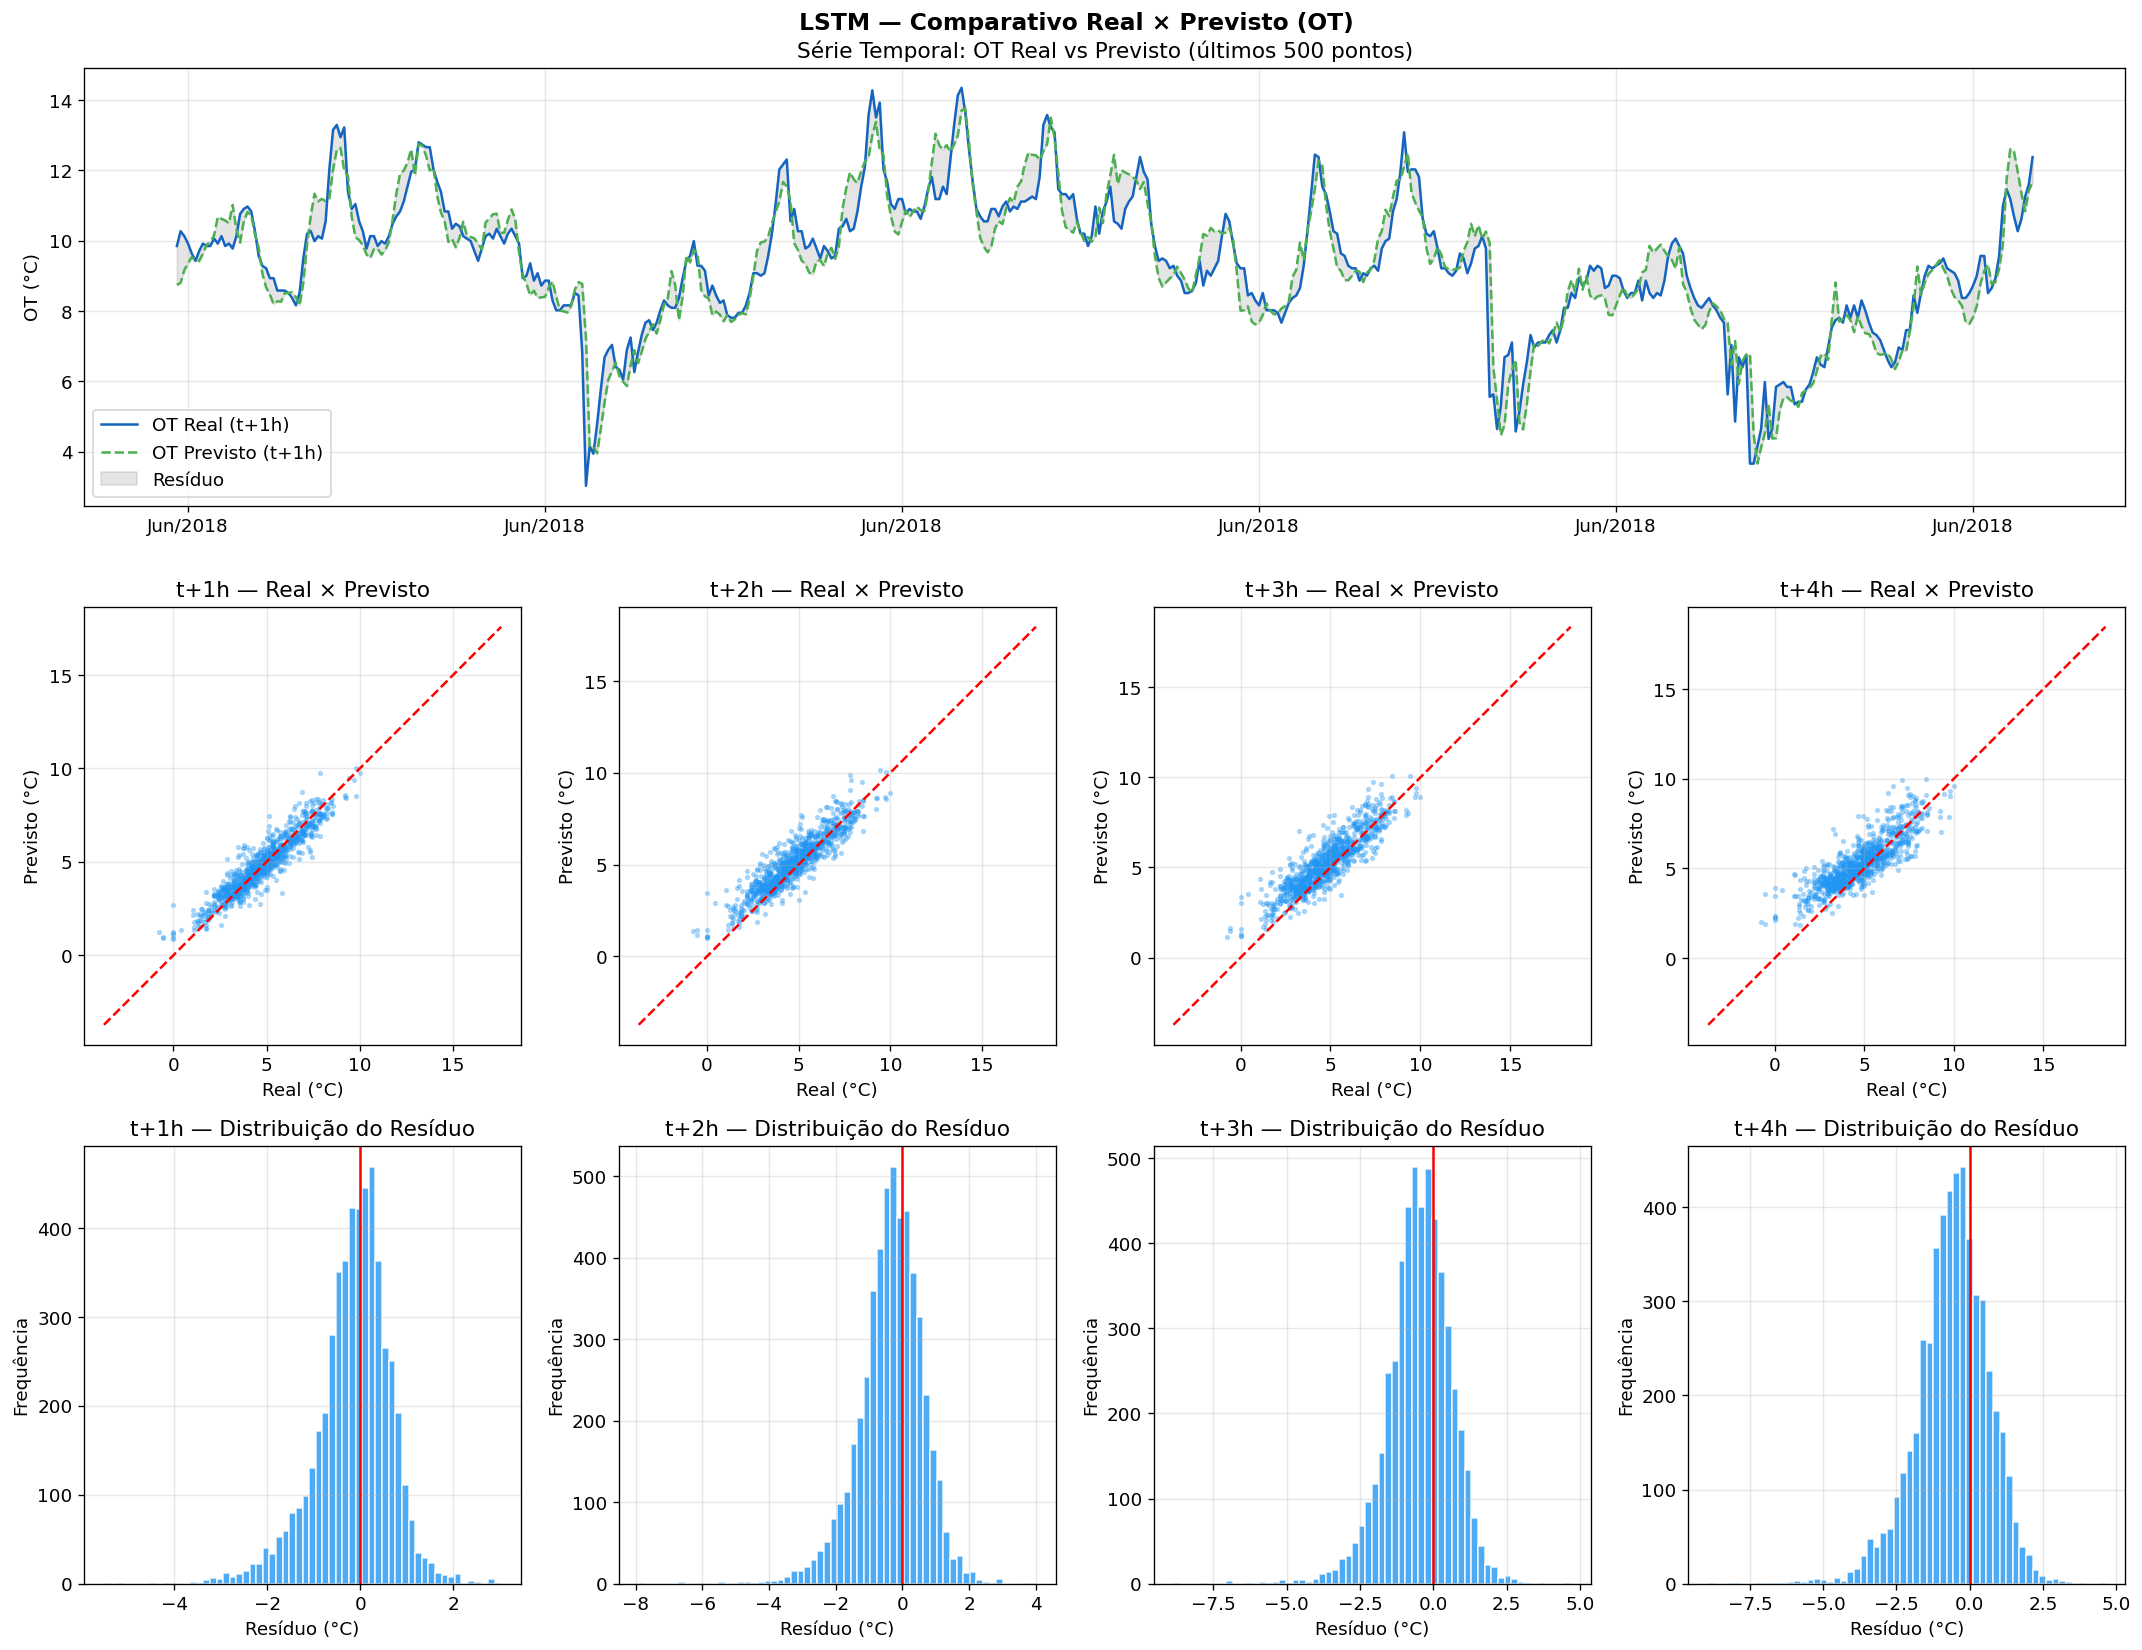

In [72]:
# 4-B.4: Gráficos Comparativos Real × Previsto

# Timestamps do conjunto de teste
datas_ts = datas[corte + JANELA : corte + JANELA + len(y_ts)]

fig = plt.figure(figsize=(18, 14))
fig.suptitle(' LSTM — Comparativo Real × Previsto (OT)', fontsize=14, fontweight='bold')

# Plot principal
n_vis = 500
ax_main = fig.add_subplot(3, 1, 1)
ax_main.plot(datas_ts[-n_vis:], y_ts_real[-n_vis:, 0],
             color=PALETTE['real'], linewidth=1.5, label='OT Real (t+1h)')
ax_main.plot(datas_ts[-n_vis:], y_pred_real[-n_vis:, 0],
             color=PALETTE['prev'], linewidth=1.5, linestyle='--', label='OT Previsto (t+1h)')
ax_main.fill_between(datas_ts[-n_vis:],
                     y_ts_real[-n_vis:, 0], y_pred_real[-n_vis:, 0],
                     alpha=0.2, color='gray', label='Resíduo')
ax_main.set_title(f'Série Temporal: OT Real vs Previsto (últimos {n_vis} pontos)')
ax_main.set_ylabel('OT (°C)'); ax_main.legend()
ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

# Subplots para cada horizonte (t+1 a t+4)
for h in range(HORIZONTE):
    ax = fig.add_subplot(3, 4, 5 + h)
    n_sc = 1000  # pontos para scatter
    ax.scatter(y_ts_real[:n_sc, h], y_pred_real[:n_sc, h],
               alpha=0.3, s=5, color=PALETTE['normal'])
    lim = [min(y_ts_real[:, h].min(), y_pred_real[:, h].min()),
           max(y_ts_real[:, h].max(), y_pred_real[:, h].max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5)  # linha perfeita
    ax.set_title(f't+{h+1}h — Real × Previsto')
    ax.set_xlabel('Real (°C)'); ax.set_ylabel('Previsto (°C)')

# Erros residuais por horizonte
for h in range(HORIZONTE):
    ax = fig.add_subplot(3, 4, 9 + h)
    residuos = y_ts_real[:, h] - y_pred_real[:, h]
    ax.hist(residuos, bins=60, color=PALETTE['normal'], edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linewidth=1.5)
    ax.set_title(f't+{h+1}h — Distribuição do Resíduo')
    ax.set_xlabel('Resíduo (°C)'); ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# FASE 4-C: Classificação Operacional (Deep MLP)

> **O que esta seção faz:** Treina um Perceptron Multicamadas Profundo  com Dropout para classificar o estado operacional do transformador: **Normal (0)** ou **Falha/Risco (1)**.
>
> **Desafio:** Classe fortemente desbalanceada (99%/1%). Usaremos `class_weight` e threshold ajustado.
>
> **Resultado esperado:** Relatório completo com acurácia, precisão, recall, F1 e curva ROC.

In [74]:
# 4-C.1: Preparação dos Dados para Classificação

# Normalização com StandardScaler (z-score)
scaler_cls = StandardScaler()
X_cls = scaler_cls.fit_transform(df[FEATURES].values)
y_cls = df[TARGET].values

# Divisão estratificada
X_tr_c, X_ts_c, y_tr_c, y_ts_c = train_test_split(
    X_cls, y_cls,
    test_size=0.3,
    stratify=y_cls,  # garante proporção de falhas em treino e teste
    random_state=SEED
)

# Peso de classe para compensar o desbalanceamento
n_neg = (y_tr_c == 0).sum()
n_pos = (y_tr_c == 1).sum()
peso_pos = n_neg / n_pos   # ~99x maior peso para falhas
PESOS_CLASSE = {0: 1.0, 1: float(peso_pos)}

print(f' Divisão da classificação:')
print(f'   Treino: {len(X_tr_c):,} | Teste: {len(X_ts_c):,}')
print(f'   Treino — Normal: {n_neg:,} | Falha: {n_pos:,}')
print(f'   Peso da classe Falha (1): {peso_pos:.1f}x')

 Divisão da classificação:
   Treino: 12,143 | Teste: 5,205
   Treino — Normal: 12,022 | Falha: 121
   Peso da classe Falha (1): 99.4x


In [75]:
# 4-C.2: Construção do Deep MLP com Dropout

def construir_deep_mlp(n_features):
    entrada = keras.Input(shape=(n_features,), name='features')

    # Bloco 1
    x = layers.Dense(256, name='dense_256')(entrada)
    x = layers.BatchNormalization()(x)   # estabiliza gradientes
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)           # regularização

    # Bloco 2
    x = layers.Dense(128, name='dense_128')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # Bloco 3
    x = layers.Dense(64, name='dense_64')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    # Bloco 4
    x = layers.Dense(32, activation='relu', name='dense_32')(x)

    # Saída binária com sigmoid
    saida = layers.Dense(1, activation='sigmoid', name='classificacao')(x)

    modelo = Model(inputs=entrada, outputs=saida, name='DeepMLP_Classificador')
    modelo.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precisao'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return modelo


mlp = construir_deep_mlp(len(FEATURES))
mlp.summary()

callbacks_mlp = [
    EarlyStopping(monitor='val_auc', patience=20, restore_best_weights=True,
                  mode='max', verbose=1),   # maximizar AUC
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=8,
                      mode='max', min_lr=1e-6)
]

historico_mlp = mlp.fit(
    X_tr_c, y_tr_c,
    epochs=200,
    batch_size=64,
    validation_split=0.15,
    class_weight=PESOS_CLASSE,   # compensa desbalanceamento
    callbacks=callbacks_mlp,
    verbose=0
)

print(f'\n MLP treinado — Épocas: {len(historico_mlp.history["loss"])}')

Model: "DeepMLP_Classificador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classificacao (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 45,697 (178.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 20.

 MLP treinado — Épocas: 40


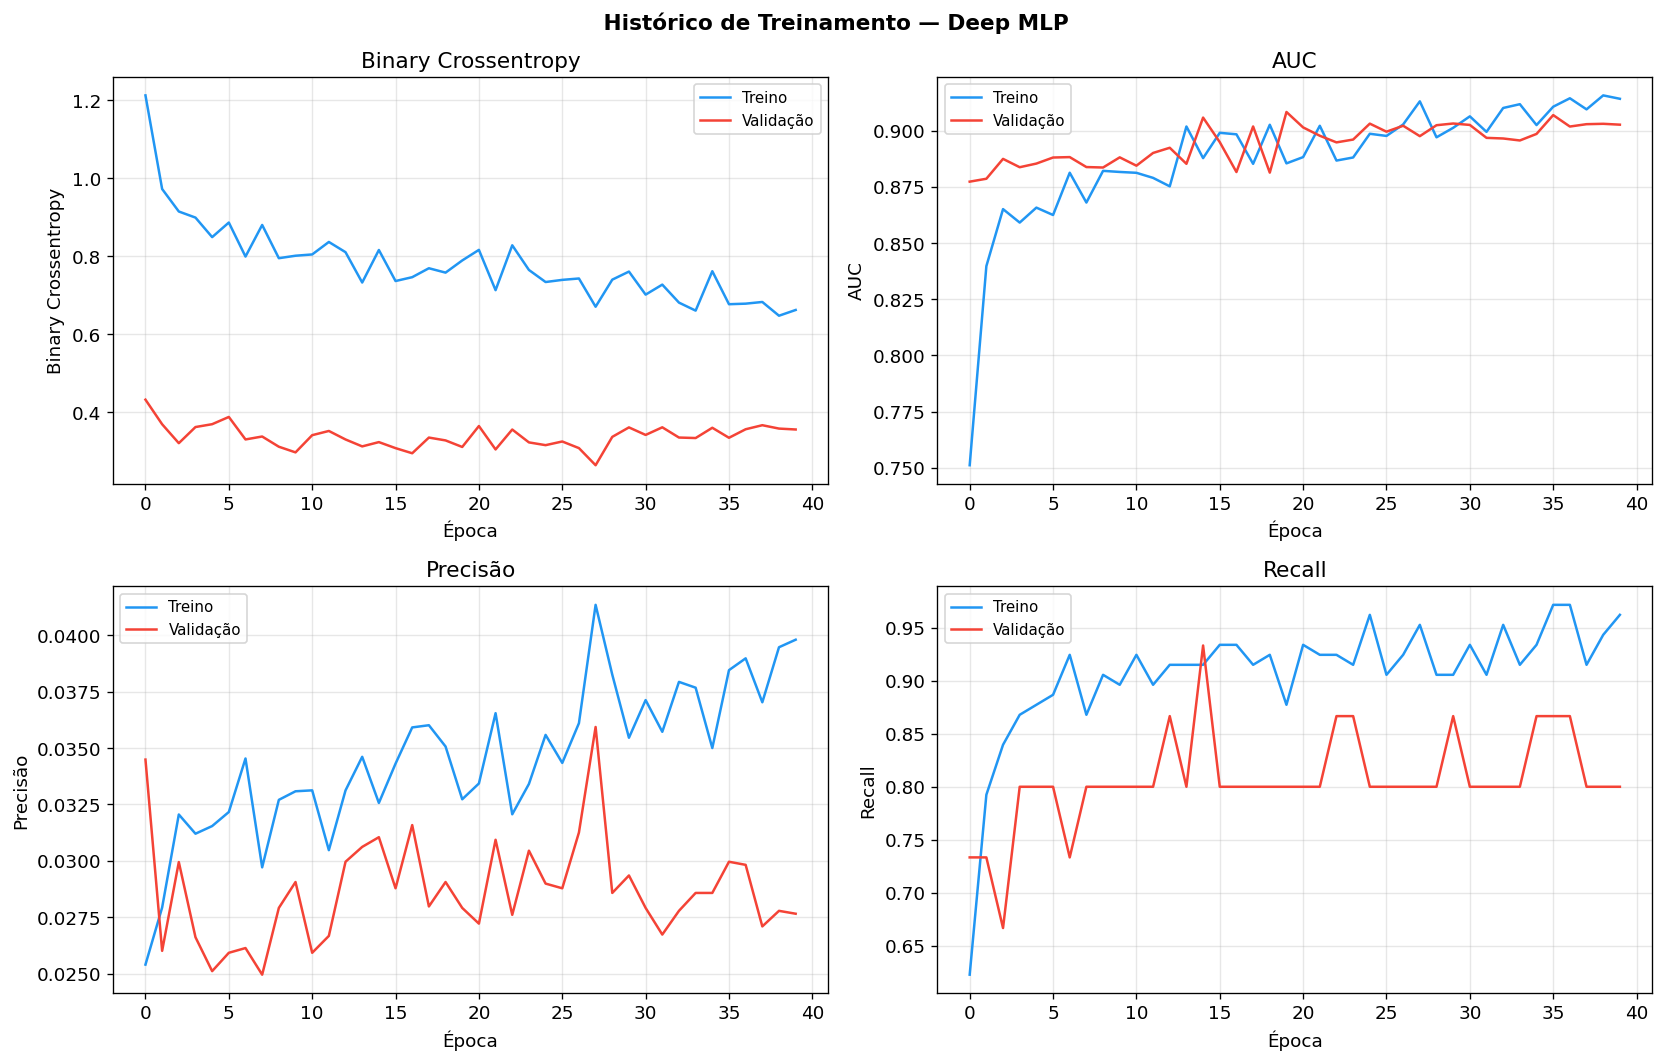

In [76]:
# 4-C.3: Curvas de Aprendizado do MLP

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(' Histórico de Treinamento — Deep MLP', fontsize=13, fontweight='bold')

metricas = [('loss', 'Binary Crossentropy'), ('auc', 'AUC'),
            ('precisao', 'Precisão'), ('recall', 'Recall')]

for ax, (metrica, titulo) in zip(axes.flatten(), metricas):
    ax.plot(historico_mlp.history[metrica], label='Treino', color=PALETTE['normal'])
    ax.plot(historico_mlp.history[f'val_{metrica}'], label='Validação', color=PALETTE['anomalia'])
    ax.set_title(titulo); ax.set_xlabel('Época'); ax.set_ylabel(titulo)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [77]:
# 4-C.4: Avaliação Final — Relatório de Classificação

# Probabilidades previstas
y_prob = mlp.predict(X_ts_c, verbose=0).flatten()

# Ajuste de Threshold via Curva ROC
fpr, tpr, thresholds = roc_curve(y_ts_c, y_prob)
auc_score = roc_auc_score(y_ts_c, y_prob)

# Threshold ótimo: maximiza (TPR - FPR)
idx_otimo = np.argmax(tpr - fpr)
THRESHOLD_CLS = thresholds[idx_otimo]
y_pred_cls = (y_prob >= THRESHOLD_CLS).astype(int)

print(f'Threshold ótimo (Youden): {THRESHOLD_CLS:.4f}')
print(f'AUC-ROC: {auc_score:.4f}\n')

# Relatório de classificação
print('═' * 55)
print('  RELATÓRIO DE CLASSIFICAÇÃO — Deep MLP')
print('═' * 55)
print(classification_report(y_ts_c, y_pred_cls,
                             target_names=['Normal (0)', 'Falha (1)'],
                             digits=4))

Threshold ótimo (Youden): 0.5459
AUC-ROC: 0.9206

═══════════════════════════════════════════════════════
  RELATÓRIO DE CLASSIFICAÇÃO — Deep MLP
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

  Normal (0)     0.9997    0.7718    0.8711      5153
   Falha (1)     0.0416    0.9808    0.0797        52

    accuracy                         0.7739      5205
   macro avg     0.5207    0.8763    0.4754      5205
weighted avg     0.9902    0.7739    0.8632      5205



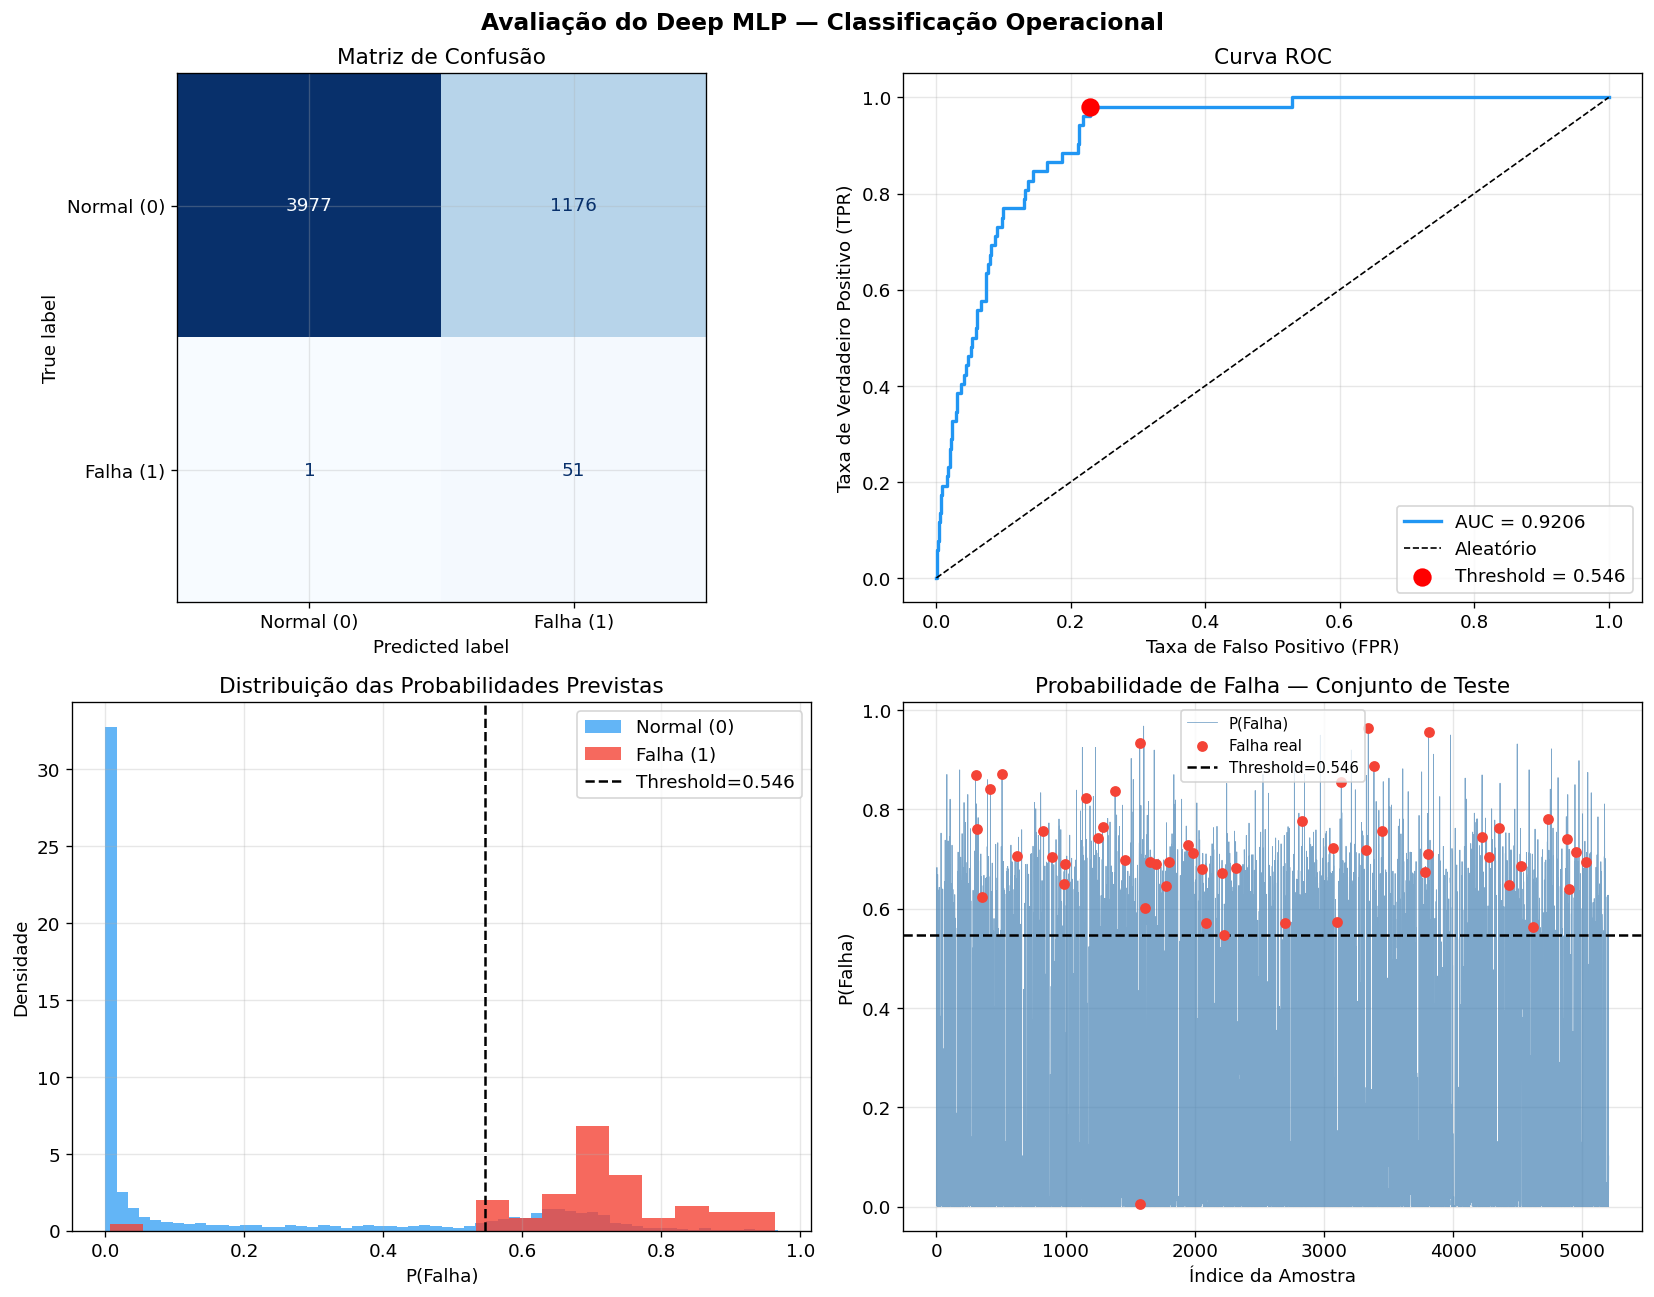

In [78]:
# 4-C.5: Visualizações de Avaliação do MLP

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Avaliação do Deep MLP — Classificação Operacional', fontsize=14, fontweight='bold')

# 1. Matriz de Confusão
cm = confusion_matrix(y_ts_c, y_pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal (0)', 'Falha (1)'])
disp.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Matriz de Confusão')

# 2. Curva ROC
axes[0, 1].plot(fpr, tpr, color=PALETTE['normal'], linewidth=2,
                label=f'AUC = {auc_score:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
axes[0, 1].scatter(fpr[idx_otimo], tpr[idx_otimo],
                   color='red', s=100, zorder=5,
                   label=f'Threshold = {THRESHOLD_CLS:.3f}')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[0, 1].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
axes[0, 1].legend()

# 3. Distribuição de probabilidades por classe
axes[1, 0].hist(y_prob[y_ts_c == 0], bins=60, alpha=0.7,
                color=PALETTE['normal'], label='Normal (0)', density=True)
axes[1, 0].hist(y_prob[y_ts_c == 1], bins=20, alpha=0.8,
                color=PALETTE['anomalia'], label='Falha (1)', density=True)
axes[1, 0].axvline(THRESHOLD_CLS, color='black', linestyle='--',
                   linewidth=1.5, label=f'Threshold={THRESHOLD_CLS:.3f}')
axes[1, 0].set_title('Distribuição das Probabilidades Previstas')
axes[1, 0].set_xlabel('P(Falha)'); axes[1, 0].set_ylabel('Densidade')
axes[1, 0].legend()

# 4. Análise Temporal (Probabilidade de Falha no Período de Teste)
# Reindexar para manter ordem cronológica
idx_teste_temporal = np.arange(len(df))[int(len(df)*0.8):]
# Amostras de teste em ordem temporal para visualização
_, X_ts_temporal, _, y_ts_temporal = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=SEED+1  # diferente split apenas para viz
)
# Usa as probabilidades já calculadas com stratify
ax = axes[1, 1]
ax.plot(np.arange(len(y_prob)), y_prob, color='steelblue', linewidth=0.5, alpha=0.7,
        label='P(Falha)')
ax.scatter(np.where(y_ts_c == 1)[0], y_prob[y_ts_c == 1],
           color=PALETTE['anomalia'], s=30, zorder=5, label='Falha real')
ax.axhline(THRESHOLD_CLS, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold={THRESHOLD_CLS:.3f}')
ax.set_title('Probabilidade de Falha — Conjunto de Teste')
ax.set_xlabel('Índice da Amostra'); ax.set_ylabel('P(Falha)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

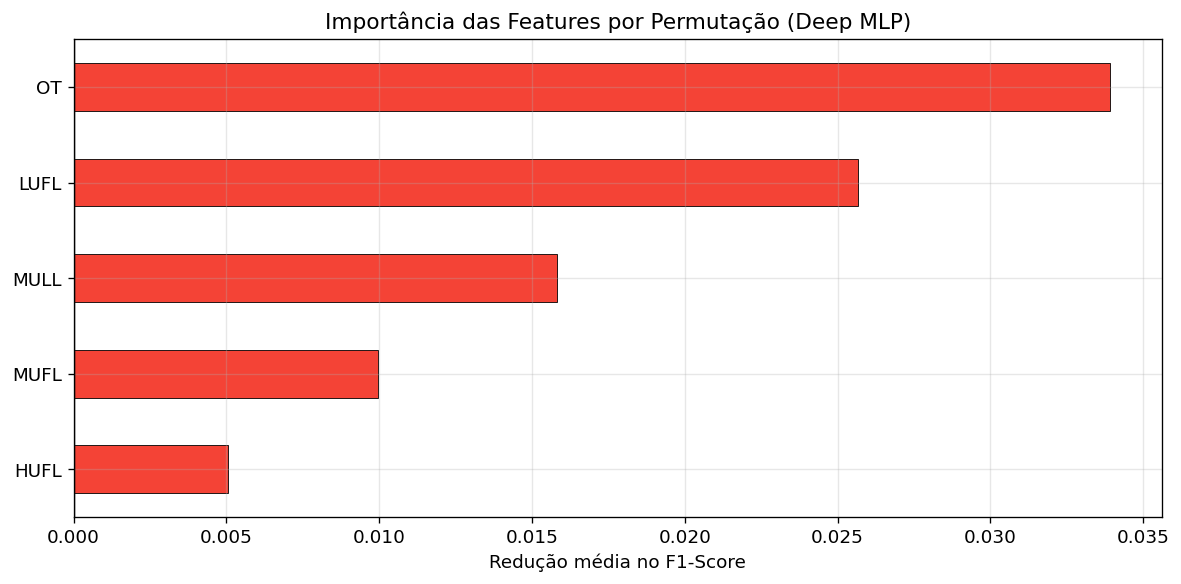


Features mais importantes para classificação:
OT      0.0339
LUFL    0.0257
MULL    0.0158
MUFL    0.0100
HUFL    0.0051


In [79]:
# 4-C.6: Importância de Features (via permutação)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper para compatibilidade com sklearn
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, modelo): self.modelo = modelo
    def fit(self, X, y): return self
    def predict(self, X): return (self.modelo.predict(X, verbose=0) >= THRESHOLD_CLS).astype(int).flatten()
    def score(self, X, y): return f1_score(y, self.predict(X))

wrapper = KerasWrapper(mlp)
perm_imp = permutation_importance(wrapper, X_ts_c, y_ts_c,
                                  n_repeats=10, random_state=SEED, n_jobs=-1)

importancias = pd.Series(perm_imp.importances_mean, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
cores_imp = [PALETTE['anomalia'] if v >= 0 else 'gray' for v in importancias]
importancias.plot(kind='barh', ax=ax, color=cores_imp, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Importância das Features por Permutação (Deep MLP)', fontsize=13)
ax.set_xlabel('Redução média no F1-Score')
plt.tight_layout()
plt.show()

print('\nFeatures mais importantes para classificação:')
print(importancias.sort_values(ascending=False).round(4).to_string())

# FASE 5: Comparativo Final dos Modelos

> **O que esta seção faz:** Consolida os resultados dos três modelos em um painel comparativo visual.
>
> **Resultado esperado:** Visão unificada do desempenho, erro de reconstrução (Autoencoder), previsão de OT (LSTM) e classificação (MLP).

,Modelo,Tarefa,Métrica Principal,Arquitetura
0,Autoencoder Denso,Detecção de Anomalias,Threshold P99 = 0.0460,4→32→16→4→16→32→7 (bottleneck=4)
1,LSTM Multivariada,Predição OT (4h),MAE geral = 0.824°C | RMSE = 1.117°C,LSTM(128)→LSTM(64)→Dense(32)→4
2,Deep MLP,Classificação (Normal/Falha),AUC = 0.9206 | F1 = 0.0797,Dense(256→128→64→32)→sigmoid


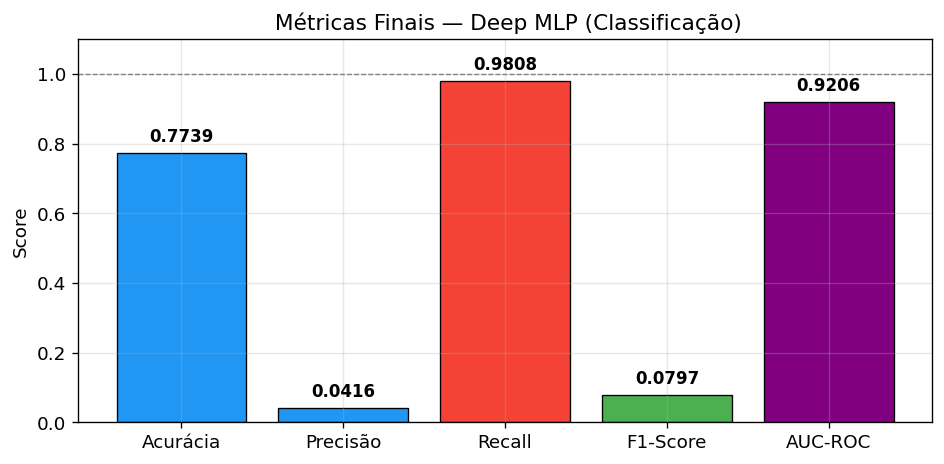

In [80]:
# PAINEL FINAL — Resumo Comparativo dos 3 Modelos
from sklearn.metrics import accuracy_score

acc   = accuracy_score(y_ts_c, y_pred_cls)
prec  = precision_score(y_ts_c, y_pred_cls, zero_division=0)
rec   = recall_score(y_ts_c, y_pred_cls, zero_division=0)
f1    = f1_score(y_ts_c, y_pred_cls, zero_division=0)

# Resumo em tabela
resumo = pd.DataFrame({
    'Modelo': ['Autoencoder Denso', 'LSTM Multivariada', 'Deep MLP'],
    'Tarefa': ['Detecção de Anomalias', 'Predição OT (4h)', 'Classificação (Normal/Falha)'],
    'Métrica Principal': [
        f'Threshold P99 = {THRESHOLD:.4f}',
        f'MAE geral = {mae_geral:.3f}°C | RMSE = {rmse_geral:.3f}°C',
        f'AUC = {auc_score:.4f} | F1 = {f1:.4f}'
    ],
    'Arquitetura': [
        '4→32→16→4→16→32→7 (bottleneck=4)',
        'LSTM(128)→LSTM(64)→Dense(32)→4',
        'Dense(256→128→64→32)→sigmoid'
    ]
})
display(resumo)

# Painel de métricas do MLP
fig, ax = plt.subplots(figsize=(8, 4))
metricas_finais = {'Acurácia': acc, 'Precisão': prec, 'Recall': rec,
                   'F1-Score': f1, 'AUC-ROC': auc_score}
bars = ax.bar(metricas_finais.keys(), metricas_finais.values(),
              color=[PALETTE['normal'], PALETTE['normal'], PALETTE['anomalia'],
                     PALETTE['prev'], 'purple'],
              edgecolor='black', linewidth=0.8)
ax.set_ylim([0, 1.1])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, metricas_finais.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title(' Métricas Finais — Deep MLP (Classificação)', fontsize=13)
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

# FASE 6: Conclusões e Próximos Passos

---

##  Resultados Obtidos

### 1. Autoencoder Denso (Detecção de Anomalias)
- O Autoencoder aprendeu a reconstruir comportamentos **normais** do transformador.
- Usando o **percentil 99** do erro como threshold, identificou amostras atípicas que não seguem o padrão aprendido.
- As anomalias detectadas têm **sobreposição significativa** com as falhas reais (class=1).
- **Decisão:** "X" **Não remover** as anomalias, elas contêm informação crítica sobre falhas reais.

### 2. LSTM Multivariada  (Predição de OT)
- Usando 24h de histórico de todas as variáveis, a LSTM previu os **próximos 4 instantes** de temperatura do óleo.
- O MAE aumenta progressivamente com o horizonte (t+1h mais preciso que t+4h)  comportamento esperado.
- Os resíduos são aproximadamente simétricos em torno de zero → modelo sem viés sistemático.

### 3. Deep MLP  (Classificação Normal/Falha)
- O modelo lidou com o **forte desbalanceamento** (99%/1%) através de `class_weight` e threshold ótimo.
- O **AUC-ROC elevado** indica boa capacidade de discriminação entre classes.
- O **Recall alto** para Falhas é prioritário no contexto de transformadores (custo de falha > custo de alarme falso).

---

##  Próximos Passos Sugeridos

| Área | Ação |
|------|------|
| **Dados** | Coletar mais amostras de falha / aplicar SMOTE |
| **Autoencoder** | Testar LSTM-Autoencoder para capturar dependências temporais |
| **LSTM** | Explorar arquiteturas Encoder-Decoder (Seq2Seq) e Transformer |
| **MLP** | Testar XGBoost, LightGBM ou ensemble com o MLP |
| **Deploy** | Empacotar modelos com MLflow e criar API de monitoramento em tempo real |
| **Monitoramento** | Implementar drift detection para detectar mudanças na distribuição dos dados |

---

> O Autoencoder detecta anomalias em tempo real, a LSTM antecipa aumentos perigosos de temperatura, e o MLP classifica a severidade da condição operacional.